The purpose of this notebook is to evaluate the ML solution to estimating joint PDFs of aerosol size and concentration

Baseline NLL against (coarse) histograms?

use the training data to estimate histgrams with bin widths optimized using validation data.
Then evaluate the NLL of those PDFs on the test data.  Compare the result to the ML solution.
Building the histograms requires we do a grid search over all possible inputs

copy data from plimpton:

```
rsync -avh -e ssh mhayman@gurgle.eol.ucar.edu:/h/eol/mhayman/Documents/aerosol_pdf_publication/ $HOME/Documents/aerosol_pdf_publication/
```

Convert `png` to `pdf` on Mac:
```
for f in *.png; do sips -s format pdf "$f" --out "${f%.png}.pdf"; done
```

In [19]:
import os
import sys
import torch
# import logging
import torch.nn as nn
# import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
# from torch.autograd import Variable
# import torchvision.models as models

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scipy.special import gamma, gammaln

import copy
import datetime
import yaml

import importlib

# import tqdm
from tqdm.notebook import tqdm

In [20]:
dirP_str = os.path.join(os.environ['HOME'], 
                    'PythonScripts',
                    'aerosol-scattering',
                    'library')
if dirP_str not in sys.path:
    sys.path.append(dirP_str)
    
import evid_nn
import data

In [21]:
is_cuda = torch.cuda.is_available()
device = torch.device(torch.cuda.current_device()) if is_cuda else torch.device("cpu")

# device= torch.device("cpu")

if is_cuda:
    torch.backends.cudnn.benchmark = True

print(f'Preparing to use device {device}')

Preparing to use device cuda:0


In [22]:
model_path = "/export/breeze1/mhayman/aerosol_poly_nn/models/"

In [23]:
save_fig_path = "/h/eol/mhayman/Documents/aerosol_pdf_publication/figs"

In [24]:
# train model on refractive index from 1.3-1.5 and 0.0-0.06
model_str_lst = [
    "20260310T065310",  # 6 beta, 2 alpha all refractive indices
    "20260311T110300",  # 3 beta, 2 alpha all refractive indices
    "20260324T070054",  # 1 beta, 1 alpha 355 nm, all refractive indices
    # "20260327T080000",  # 1 beta, 1 alpha 532 nm, all refractive indices
    "20260507T072534",  # 3 beta, 0 alpha, all refractive indices
]

In [25]:
example_count = 10

# idx_arr = np.array([18334])
# idx_arr = np.array([60308, 11462, 44852,  6123, 41998, 50674, 87012, 87725, 87707, 17718])
idx_arr = np.array([60308, 11462, 44852,  6123, 41998, 50674, 87012, 87725, 87707, 18334, 44305, 44535, 49700, 55717, 55721, 55744,
        55875, 55960, 56042, 56201, 56414, 56527, 56740, 56798, 56810,
        56822, 56823, 62837, 65213, 53289])

In [26]:
# store results from optimizing the histogram bins for each model
model_opt_hist_dct = {
    "20260310T065310":{
        "input_bins": 53,
        "output_bins": 43
    },
    "20260311T110300":{
        "input_bins": 114,
        "output_bins": 43
    },
    "20260324T070054":{
        "input_bins": 190,
        "output_bins": 79
    },
    "20260327T080000":{
        "input_bins": 190,
        "output_bins": 108
    },
}

# model: 20260310T065310
# optimal input bins: 53
# optimal output bins: 43

# model: 20260311T110300
# optimal input bins: 114
# optimal output bins: 43

# model: 20260324T070054
# optimal input bins: 190
# optimal output bins: 79

# model: 20260327T080000
# optimal input bins: 190
# optimal output bins: 108

# Post Analysis of Models
Analysis has already been run and saved out to netcdf files

In [27]:
model_file_lst = [
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/20260310T065310_Model_Eval_PostAnalysis.nc",
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/20260311T110300_Model_Eval_PostAnalysis.nc",
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/20260324T070054_Model_Eval_PostAnalysis.nc",
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/20260327T080000_Model_Eval_PostAnalysis.nc",
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/20260507T072534_Model_Eval_PostAnalysis.nc", # 3 beta 0 alpha
]



In [28]:
ds_lst = []
for file in model_file_lst:
    ds_lst.append(xr.open_dataset(file))

In [29]:
for ds in ds_lst:
    print("Model: "+ ds.attrs['model'])
    eval_idx = np.where(ds['test_eval_idx'].values > 0)
    omitted_pts = ds['test_eval_idx'].values.size - np.sum(ds['test_eval_idx'].values)
    print(f"Histogram test NLL: {np.sum(ds['test_hist_nll'].values[eval_idx])}")
    print(f"filtered point count: {omitted_pts} ({100*omitted_pts/ds['test_eval_idx'].values.size:.02f}%)")
    print(f"NN test NLL (filtered): {np.sum(ds['test_nn_nll'].values[eval_idx])}")
    print(f"NN test NLL (unfiltered): {np.sum(ds['test_nn_nll'].values)}")
    print()
    

Model: 20260310T065310
Histogram test NLL: -12663576.409396565
filtered point count: 207332 (6.31%)
NN test NLL (filtered): -16700992.645489417
NN test NLL (unfiltered): -17604721.35716484

Model: 20260311T110300
Histogram test NLL: -12914646.846413221
filtered point count: 260602 (7.94%)
NN test NLL (filtered): -14806078.114526566
NN test NLL (unfiltered): -15813285.193176294

Model: 20260324T070054
Histogram test NLL: -11327160.659983002
filtered point count: 76926 (2.34%)
NN test NLL (filtered): -11329437.949366044
NN test NLL (unfiltered): -11458177.71067091

Model: 20260327T080000
Histogram test NLL: -11435639.676845668
filtered point count: 101998 (3.11%)
NN test NLL (filtered): -11387385.670924645
NN test NLL (unfiltered): -11585498.955358712

Model: 20260507T072534
Histogram test NLL: -11937106.982310213
filtered point count: 158044 (4.81%)
NN test NLL (filtered): -12242200.056224488
NN test NLL (unfiltered): -12555565.321678806



In [30]:
ds['test_eval_idx'].values.size

3283252

In [31]:
ds['test_eval_idx'].values.shape

(3283252,)

In [32]:
ds_lst[0]

<xarray.Dataset> Size: 536MB
Dimensions:              (test_data: 3283252, example_idx: 30,
                          nn_conc_bins: 1000, nn_rad_bins: 1000,
                          hist_conc_bins: 43, hist_rad_bins: 43)
Coordinates:
  * example_idx          (example_idx) int64 240B 60308 11462 ... 65213 53289
  * nn_conc_bins         (nn_conc_bins) float64 8kB 1.254 1.266 ... 1.778e+04
  * nn_rad_bins          (nn_rad_bins) float64 8kB 3.086e-08 ... 4.829e-07
  * hist_conc_bins       (hist_conc_bins) float64 344B 1.254 1.567 ... 1.423e+04
  * hist_rad_bins        (hist_rad_bins) float64 344B 3.086e-08 ... 4.53e-07
Dimensions without coordinates: test_data
Data variables:
    test_hist_nll        (test_data) float64 26MB -1.112 -1.112 ... -2.429
    test_eval_idx        (test_data) bool 3MB True True True ... True True True
    test_nn_nll          (test_data) float64 26MB -0.5344 -0.8365 ... -4.367
    nn_pdf_examples      (example_idx, nn_conc_bins, nn_rad_bins) float64 240MB ...
    nn_ens_pdf_examples  (example_idx, nn_conc_bins, nn_rad_bins) float64 240MB ...
    hist_pdf_examples    (example_idx, hist_conc_bins, hist_rad_bins) float64 444kB ...
Attributes:
    model:         20260310T065310
    description:   analysis of NN model performance for aerosol size/concentr...
    label_params:  $\alpha$, $\beta$
    label_wl:      1064, 710, 800, 532, 400, 355

# Plot example PDFs

In [33]:
model_file_lst = [
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/20260310T065310_Model_Eval_PostAnalysis_Examples.nc",
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/20260311T110300_Model_Eval_PostAnalysis_Examples.nc",
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/20260324T070054_Model_Eval_PostAnalysis_Examples.nc",
    # "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/20260327T080000_Model_Eval_PostAnalysis_Examples.nc",
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/20260507T072534_Model_Eval_PostAnalysis_Examples.nc", # 3 beta 0 alpha
]

In [34]:
ds_lst = []
for file in model_file_lst:
    ds_lst.append(xr.open_dataset(file))

In [35]:
custom_label_lst = [r'6$\beta$+2$\alpha$',r'3$\beta$+2$\alpha$', r'355 nm', r'3$\beta$'] # r'532 nm'

In [36]:
test_ds = xr.open_dataset(os.path.join("/export/breeze1/mhayman/aerosol_poly_nn/datasets/","hippo_aerosol_index_training_data.nc"))
# test_ds.close()

838026


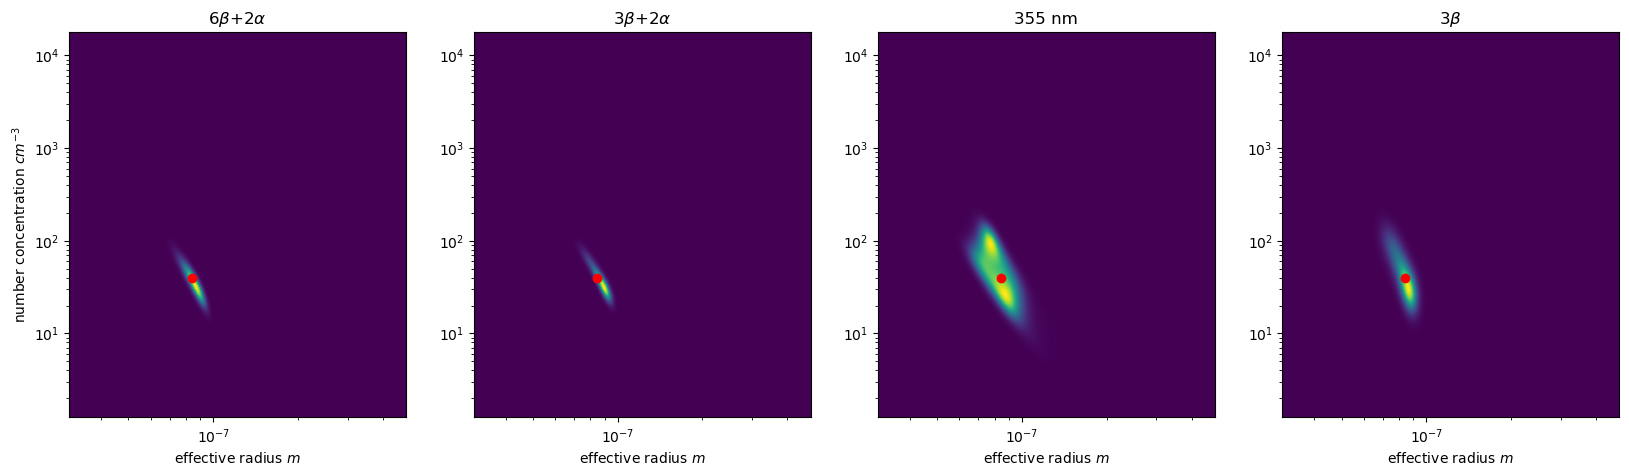

In [37]:
ex_idx = 12 # extra 150 examples: 1, *2, *6, 7, *9, 10 # base 30 examples: 2, 3, 6, 7, 10, 13, 16, 17, 18, 19, 20, 21, 22, 25
n_col = 4
n_row = int(np.ceil(len(ds_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, ds in enumerate(ds_lst):
    f_pdf = ds['nn_pdf_examples'].isel(example_idx=ex_idx).values
    ax = ax_lst[m_idx]
    test_data_idx = ds['example_idx'].values[ex_idx]
    ax.pcolormesh(ds['nn_rad_bins'],ds['nn_conc_bins'],f_pdf)
    ax.scatter(ds['effective_radius'].isel(example_idx=ex_idx),
               ds['number_concentration'].isel(example_idx=ex_idx),c='r',marker='o')
    # ax.scatter(test_ds['effective_r'].isel(data_index=test_data_idx),
    #            test_ds['number_concentration'].isel(data_index=test_data_idx),c='r',marker='o')
    ax.set_xscale('log')
    ax.set_yscale('log')
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'effective radius $m$')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'number concentration $cm^{-3}$')
    title = custom_label_lst[m_idx]
    # title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)
print(test_data_idx)

In [38]:
# test_ds['effective_r'].isel(data_index=ds['example_idx'].values).values

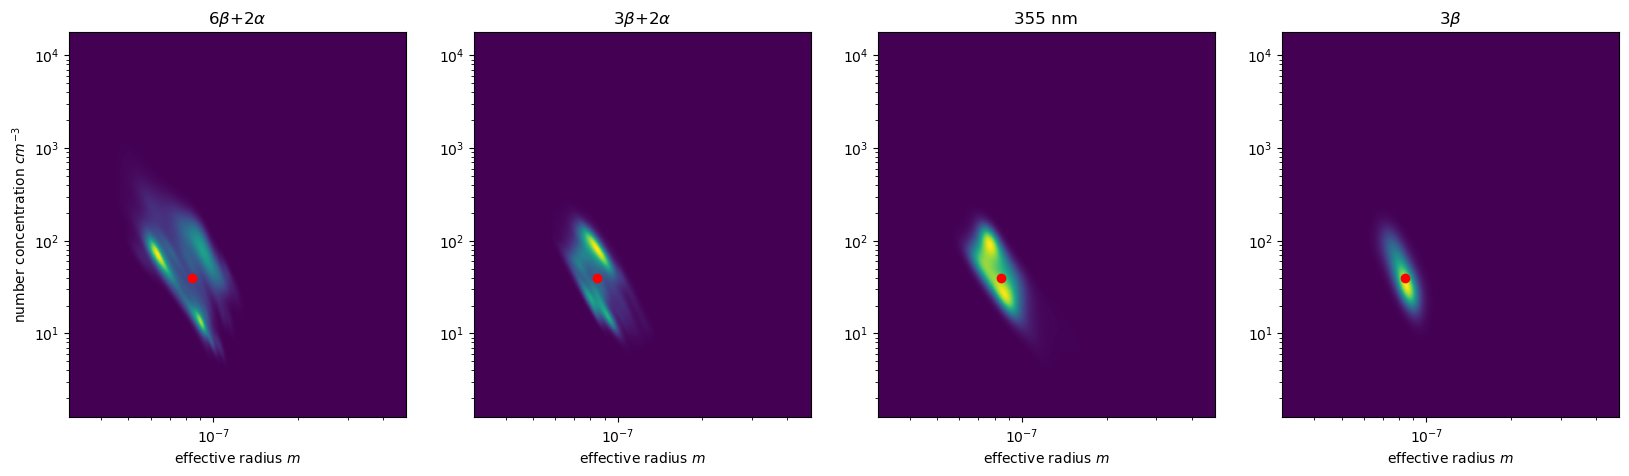

In [39]:
# ex_idx = 15
n_col = 4
n_row = int(np.ceil(len(ds_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, ds in enumerate(ds_lst):
    f_pdf = ds['nn_ens_pdf_examples'].isel(example_idx=ex_idx).values
    ax = ax_lst[m_idx]
    ax.pcolormesh(ds['nn_rad_bins'],ds['nn_conc_bins'],f_pdf)
    ax.scatter(ds['effective_radius'].isel(example_idx=ex_idx),
               ds['number_concentration'].isel(example_idx=ex_idx),c='r',marker='o')
    # ax.scatter(test_ds['effective_r'].sel(data_index=ds['example_idx'].values[ex_idx]),
    #            test_ds['number_concentration'].sel(data_index=ds['example_idx'].values[ex_idx]),c='r',marker='o')
    ax.set_xscale('log')
    ax.set_yscale('log')
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'effective radius $m$')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'number concentration $cm^{-3}$')
    title = custom_label_lst[m_idx]
    # title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

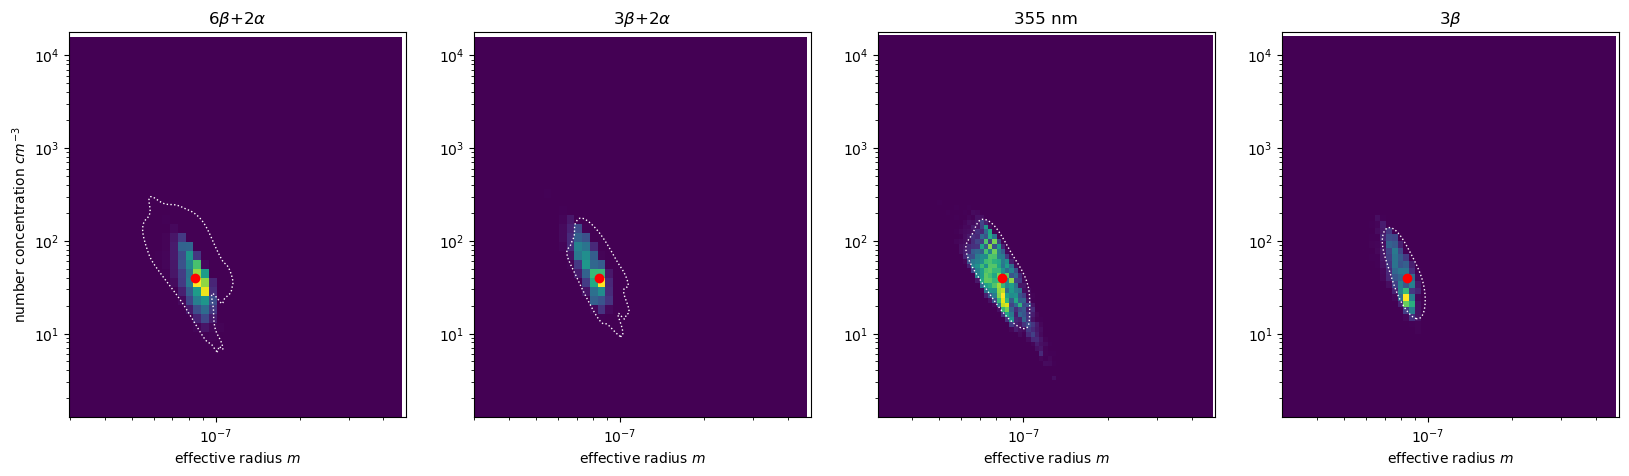

In [40]:
# ex_idx = 15
n_col = 4
n_row = int(np.ceil(len(ds_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, ds in enumerate(ds_lst):
    f_pdf = ds['hist_pdf_examples'].isel(example_idx=ex_idx).values
    ax = ax_lst[m_idx]
    ax.pcolormesh(ds['hist_rad_bins'],ds['hist_conc_bins'],f_pdf)
    pxlim = ax.get_xlim()
    pylim = ax.get_ylim()
    
    # add ensemble contour
    f_pdf = ds['nn_ens_pdf_examples'].isel(example_idx=ex_idx).values
    contour_levels = np.linspace(f_pdf.min(), f_pdf.max(),100)
    contours = ax.contour(ds['nn_rad_bins'],ds['nn_conc_bins'], f_pdf, levels = [contour_levels[10]], colors='white', linestyles=':', linewidths=1)
    ax.scatter(ds['effective_radius'].isel(example_idx=ex_idx),
               ds['number_concentration'].isel(example_idx=ex_idx),c='r',marker='o')
    # ax.scatter(test_ds['effective_r'].sel(data_index=ds['example_idx'].values[ex_idx]),
    #            test_ds['number_concentration'].sel(data_index=ds['example_idx'].values[ex_idx]),c='r',marker='o')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'effective radius $m$')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'number concentration $cm^{-3}$')
    title = custom_label_lst[m_idx]
    # title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

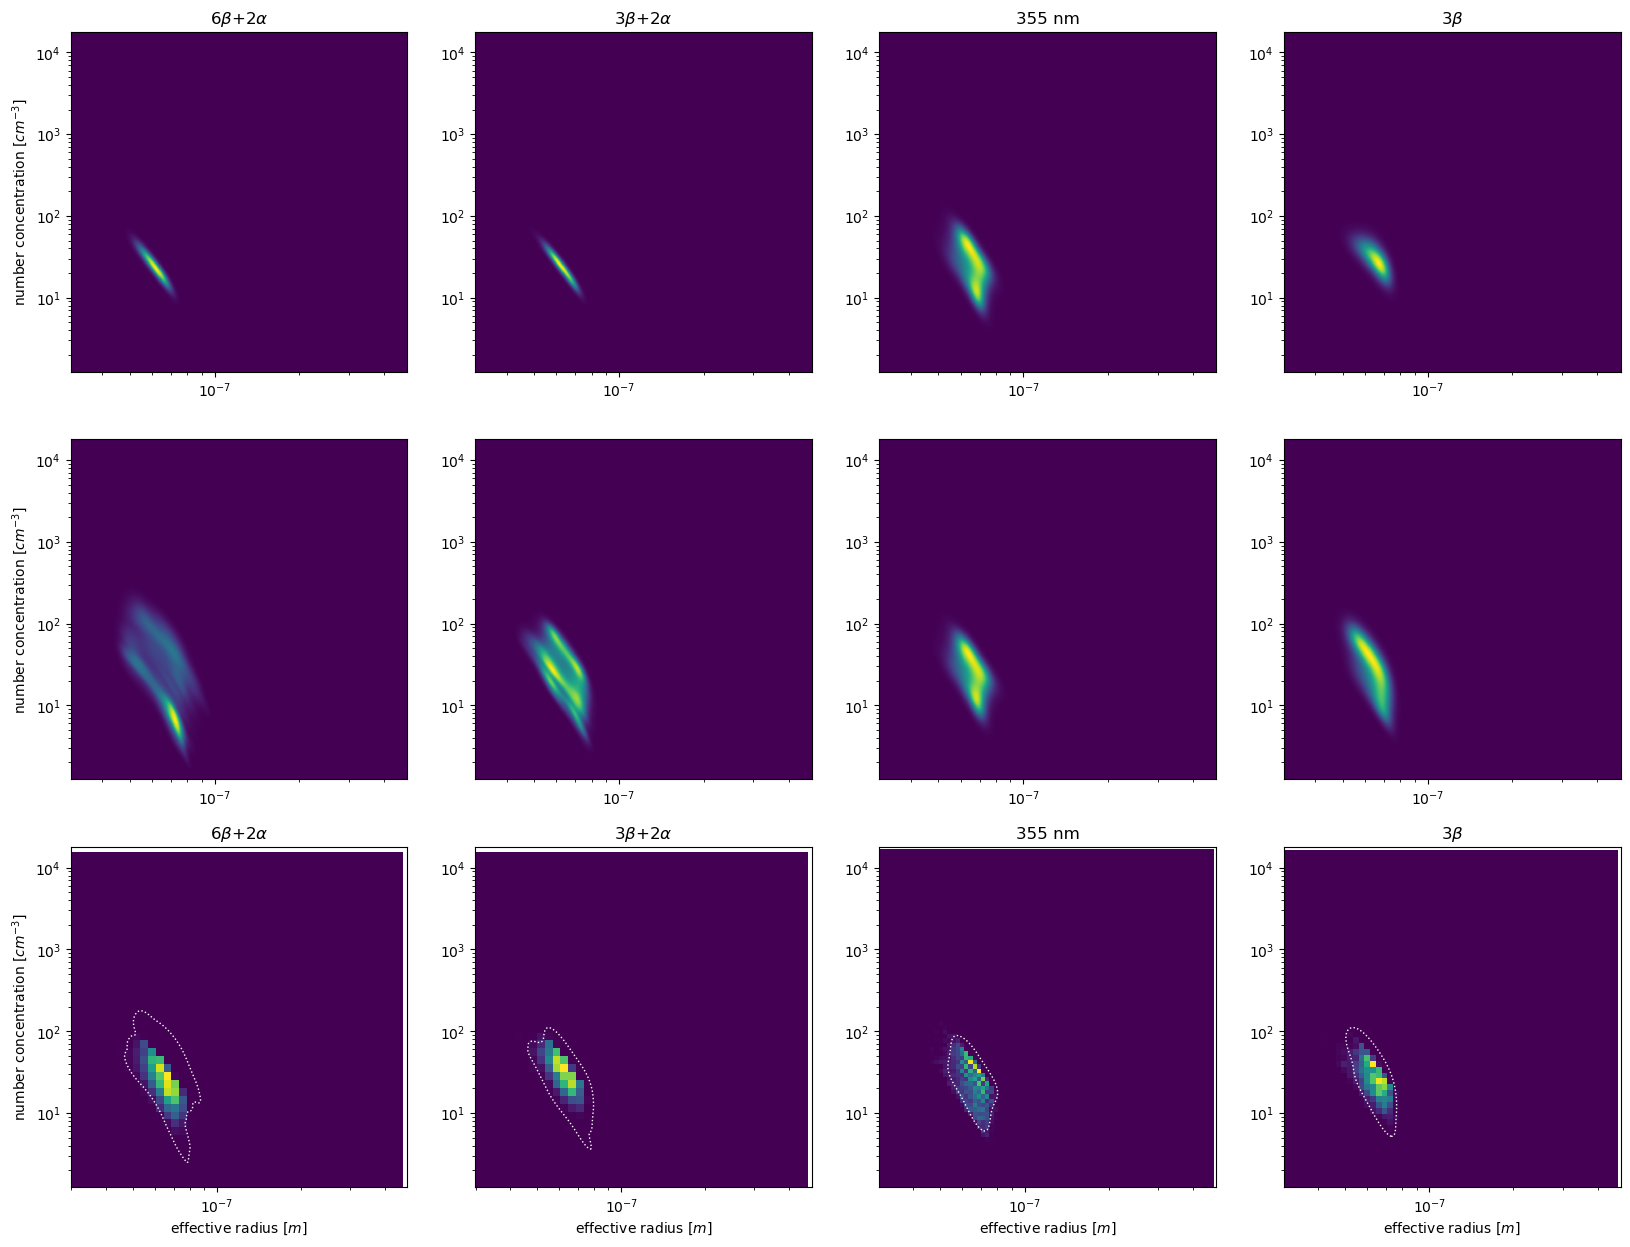

In [45]:
ex_idx = 2 # extra 150 examples: 1, *2, *6, 7, *9, 10 # base 30 examples: 2, 3, 6, 7, 10, 13, 16, 17, 18, 19, 20, 21, 22, 25
n_col = 4
n_row = 3 #int(np.ceil(len(ds_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
# ax_lst = ax_lst.ravel()
for m_idx, ds in enumerate(ds_lst):
    f_pdf = ds['nn_pdf_examples'].isel(example_idx=ex_idx).values
    ax = ax_lst[0,m_idx]
    test_data_idx = ds['example_idx'].values[ex_idx]
    ax.pcolormesh(ds['nn_rad_bins'],ds['nn_conc_bins'],f_pdf)
    # ax.scatter(ds['effective_radius'].isel(example_idx=ex_idx),
    #            ds['number_concentration'].isel(example_idx=ex_idx),c='r',marker='o')
    # # ax.scatter(test_ds['effective_r'].isel(data_index=test_data_idx),
    # #            test_ds['number_concentration'].isel(data_index=test_data_idx),c='r',marker='o')
    ax.set_xscale('log')
    ax.set_yscale('log')
    # if m_idx//n_col == n_row-1:
    #     ax.set_xlabel(r'effective radius $m$')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'number concentration [$cm^{-3}$]')
    title = custom_label_lst[m_idx]
    # title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

    f_pdf = ds['nn_ens_pdf_examples'].isel(example_idx=ex_idx).values
    ax = ax_lst[1, m_idx]
    ax.pcolormesh(ds['nn_rad_bins'],ds['nn_conc_bins'],f_pdf)
    # ax.scatter(ds['effective_radius'].isel(example_idx=ex_idx),
    #            ds['number_concentration'].isel(example_idx=ex_idx),c='r',marker='o')
    # # ax.scatter(test_ds['effective_r'].sel(data_index=ds['example_idx'].values[ex_idx]),
    # #            test_ds['number_concentration'].sel(data_index=ds['example_idx'].values[ex_idx]),c='r',marker='o')
    ax.set_xscale('log')
    ax.set_yscale('log')
    # if m_idx//n_col == n_row-1:
    #     ax.set_xlabel(r'effective radius $m$')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'number concentration [$cm^{-3}$]')
    title = custom_label_lst[m_idx]
    # title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    # ax.set_title(title)


    f_pdf = ds['hist_pdf_examples'].isel(example_idx=ex_idx).values
    ax = ax_lst[2,m_idx]
    ax.pcolormesh(ds['hist_rad_bins'],ds['hist_conc_bins'],f_pdf)
    pxlim = ax.get_xlim()
    pylim = ax.get_ylim()
    
    # add ensemble contour
    f_pdf = ds['nn_ens_pdf_examples'].isel(example_idx=ex_idx).values
    contour_levels = np.linspace(f_pdf.min(), f_pdf.max(),100)
    contours = ax.contour(ds['nn_rad_bins'],ds['nn_conc_bins'], f_pdf, levels = [contour_levels[10]], colors='white', linestyles=':', linewidths=1)
    # ax.scatter(ds['effective_radius'].isel(example_idx=ex_idx),
    #            ds['number_concentration'].isel(example_idx=ex_idx),c='r',marker='o')
    # # ax.scatter(test_ds['effective_r'].sel(data_index=ds['example_idx'].values[ex_idx]),
    # #            test_ds['number_concentration'].sel(data_index=ds['example_idx'].values[ex_idx]),c='r',marker='o')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    # if m_idx//n_col == n_row-1:
    ax.set_xlabel(r'effective radius [$m$]')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'number concentration [$cm^{-3}$]')
    title = custom_label_lst[m_idx]
    # title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

save_fig_name = f"OutputPDF_Example{ex_idx}_2.png"
plt.savefig(os.path.join(save_fig_path,save_fig_name), dpi=300, bbox_inches='tight')
    

In [42]:
m_idx//n_col

0

copy data to plimpton:
```
rsync -avh -e ssh mhayman@gurgle.eol.ucar.edu:/h/eol/mhayman/Documents/aerosol_pdf_publication/ $HOME/Documents/aerosol_pdf_publication/
```

Convert `png` to `pdf` on Mac:
```
for f in *.png; do sips -s format pdf "$f" --out "${f%.png}.pdf"; done
```

In [234]:
contour_levels[0]

np.float64(6.164004814630811e-11)

In [235]:
f_pdf.min()

np.float64(6.164004814630811e-11)

Text(0, 0.5, 'Probability')

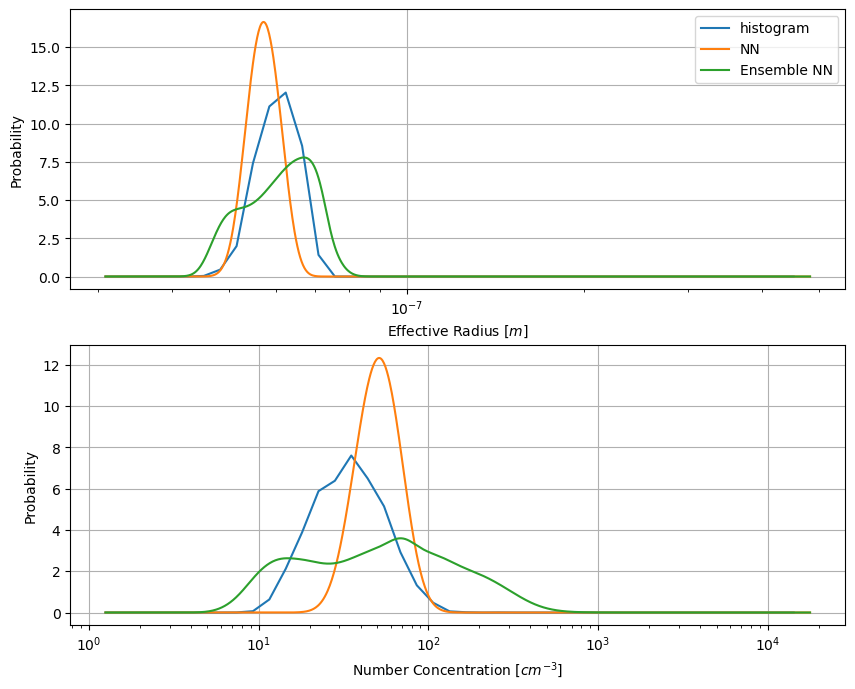

In [240]:
m_idx = 0


ds = ds_lst[m_idx]

fig,ax = plt.subplots(2,1,figsize=(10,8))
ax[0].plot(ds['hist_rad_bins'],np.sum(ds['hist_pdf_examples'].isel(example_idx=ex_idx).values,axis=0)*ds['hist_rad_bins'].size/np.sum(ds['hist_pdf_examples'].isel(example_idx=ex_idx).values),label='histogram')
ax[0].plot(ds['nn_rad_bins'],np.sum(ds['nn_pdf_examples'].isel(example_idx=ex_idx).values,axis=0)*ds['nn_rad_bins'].size/np.sum(ds['nn_pdf_examples'].isel(example_idx=ex_idx).values),label='NN')
ax[0].plot(ds['nn_rad_bins'],np.sum(ds['nn_ens_pdf_examples'].isel(example_idx=ex_idx).values,axis=0)*ds['nn_rad_bins'].size/np.sum(ds['nn_ens_pdf_examples'].isel(example_idx=ex_idx).values),label='Ensemble NN')
ax[0].set_xscale('log')
ax[0].grid(visible=True)
ax[0].set_xlabel('Effective Radius [$m$]')
ax[0].set_ylabel('Probability')
ax[0].legend()

ax[1].plot(ds['hist_conc_bins'],np.sum(ds['hist_pdf_examples'].isel(example_idx=ex_idx).values,axis=1)*ds['hist_conc_bins'].size/np.sum(ds['hist_pdf_examples'].isel(example_idx=ex_idx).values),label='histogram')
ax[1].plot(ds['nn_conc_bins'],np.sum(ds['nn_pdf_examples'].isel(example_idx=ex_idx).values,axis=1)*ds['nn_conc_bins'].size/np.sum(ds['nn_pdf_examples'].isel(example_idx=ex_idx).values),label='NN')
ax[1].plot(ds['nn_conc_bins'],np.sum(ds['nn_ens_pdf_examples'].isel(example_idx=ex_idx).values,axis=1)*ds['nn_conc_bins'].size/np.sum(ds['nn_ens_pdf_examples'].isel(example_idx=ex_idx).values),label='Ensemble NN')
ax[1].set_xscale('log')
ax[1].grid(visible=True)
ax[1].set_xlabel('Number Concentration [$cm^{-3}$]')
ax[1].set_ylabel('Probability')

NameError: name 'hist_ax' is not defined

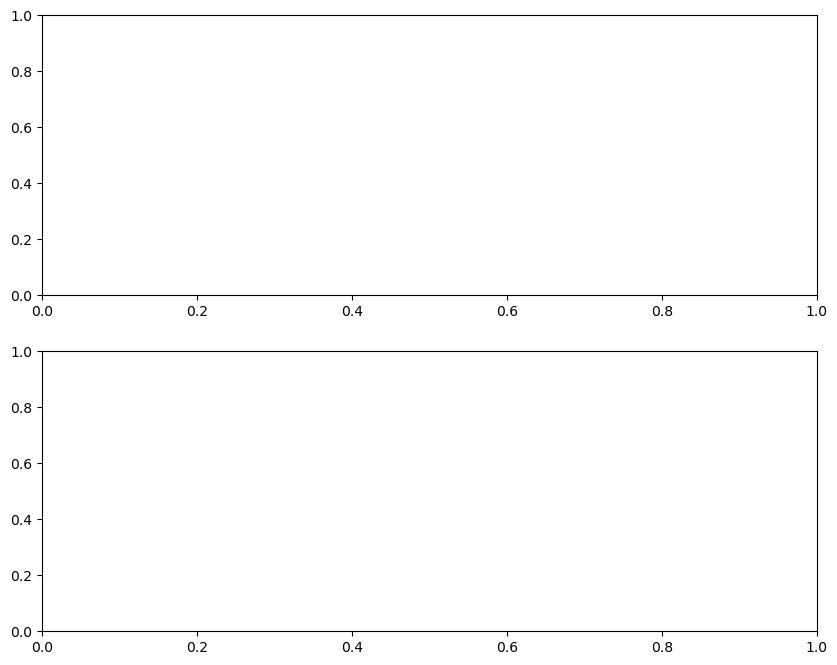

In [207]:
fig,ax = plt.subplots(2,1,figsize=(10,8))

ax[0].plot(hist_ax[1:,1],np.sum(h_part[0].T,axis=0)/np.sum(h_part[0])/np.mean(np.diff(h_part[1])),label='histogram')
ax[0].plot(pdf_ax[:,1],np.sum(f_pdf[0,...],axis=0)/np.sum(f_pdf[0,...])/np.mean(np.diff(x_plt)),label='NN')
ax[0].plot(pdf_ax[:,1],np.sum(f_pdf_ens,axis=0)/np.sum(f_pdf[0,...])/np.mean(np.diff(x_plt)),label='Ensemble NN')
ax[0].set_xscale('log')
ax[0].grid(visible=True)
ax[0].set_xlabel('Effective Radius [$m$]')
ax[0].set_ylabel('Probability')
ax[0].legend()

ax[1].plot(hist_ax[1:,0],np.sum(h_part[0].T,axis=1)/np.sum(h_part[0])/np.mean(np.diff(h_part[1])),label='histogram')
ax[1].plot(pdf_ax[:,0],np.sum(f_pdf[0,...],axis=1)/np.sum(f_pdf[0,...])/np.mean(np.diff(x_plt)),label='NN')
ax[1].plot(pdf_ax[:,0],np.sum(f_pdf_ens,axis=1)/np.sum(f_pdf[0,...])/np.mean(np.diff(x_plt)),label='Ensemble NN')
ax[1].set_xscale('log')
ax[1].grid(visible=True)
ax[1].set_xlabel('Number Concentration [$cm^{-3}$]')
ax[1].set_ylabel('Probability')

# Full Output Baseline

In [87]:
from matplotlib.lines import Line2D

In [69]:
!ls /export/breeze1/mhayman/aerosol_poly_nn/datasets/

hippo_aerosol_index_training_data.nc
hippo_aerosol_index_training_data_test.nc
hippo_aerosol_index_training_data_train.nc
hippo_aerosol_index_training_data_valid.nc
hippo_aerosol_training_data_test.nc
hippo_aerosol_training_data_train.nc
hippo_aerosol_training_data_valid.nc


In [73]:
ds_file_name_lst = [
    "hippo_aerosol_index_training_data_train.nc",
    "hippo_aerosol_index_training_data_valid.nc",
    "hippo_aerosol_index_training_data_test.nc",
]
raw_ds_lst = []
for filename in ds_file_name_lst:
    raw_ds_lst.append(xr.open_dataset(os.path.join("/export/breeze1/mhayman/aerosol_poly_nn/datasets/",filename)))

raw_ds = xr.concat(raw_ds_lst,dim=('data_index'))

In [70]:
test_ds.coords

Coordinates:
  * wavelength             (wavelength) float64 48B 1.064e-06 ... 3.55e-07
  * real_index_refraction  (real_index_refraction) float64 56B 1.3 1.35 ... 1.6
  * imag_index_refraction  (imag_index_refraction) float64 32B 0.0 0.02 ... 0.06
  * data_index             (data_index) int64 9MB 0 1 2 ... 1144604 1144605

In [99]:
conc_bins = np.logspace(0,4,200)
r_bins = np.logspace(-8,-6,100)

In [100]:
hist_full = np.histogram2d(raw_ds['effective_r'].values,raw_ds['number_concentration'].values,bins=(r_bins,conc_bins))

In [109]:
full_conc_lim = np.interp(np.array([0.05,0.95]),np.cumsum(np.sum(hist_full[0],axis=0))/np.sum(hist_full[0]),conc_bins[:-1])
full_r_lim = np.interp(np.array([0.05,0.95]),np.cumsum(np.sum(hist_full[0],axis=1))/np.sum(hist_full[0]),r_bins[:-1])
print(f"concentration spread: {full_conc_lim[1]/full_conc_lim[0]}")
print(f"radius spread: {full_r_lim[1]/full_r_lim[0]}")

concentration spread: 61.222169804566946
radius spread: 3.6085211893264524


array([5.00637440e-08, 1.80656081e-07])

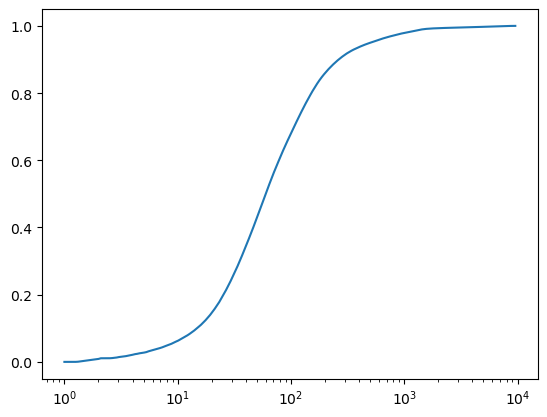

In [105]:
plt.plot(conc_bins[:-1],np.cumsum(np.sum(hist_full[0],axis=0))/np.sum(hist_full[0]))
plt.xscale('log')

In [76]:
contour_def_lst = [
    {'colors':'white','linestyles':':'},
    {'colors':'tab:orange','linestyles':'-.'},
    {'colors':'tab:red','linestyles':'--'},
    {'colors':'tab:pink','linestyles':'-'},
]

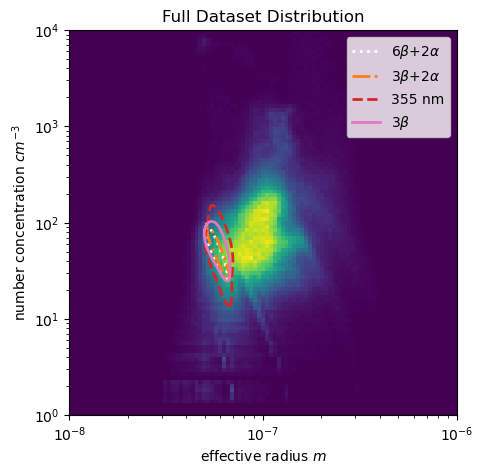

In [92]:
ex_idx = 9
fig,ax = plt.subplots(1,1,figsize=(5,5))
ax.pcolormesh(hist_full[1],hist_full[2],hist_full[0].T)

for m_idx, ds in enumerate(ds_lst):
    f_pdf = ds['nn_pdf_examples'].isel(example_idx=ex_idx).values
    contour_levels = np.linspace(f_pdf.min(), f_pdf.max(),100)
    contplt = contours = ax.contour(ds['nn_rad_bins'],ds['nn_conc_bins'], f_pdf, levels = [contour_levels[10]],linewidths=2,**contour_def_lst[m_idx])
    
# 2. Create proxy artists using your definitions
artists_lst = [
    Line2D([0], [0], color=style['colors'], linestyle=style['linestyles'], lw=2) 
    for style in contour_def_lst
]
    
# 3. Call the legend with the proxy artists
ax.legend(artists_lst, custom_label_lst)

ax.set_xlim([hist_full[1][0],hist_full[1][-1]])
ax.set_ylim([hist_full[2][0],hist_full[2][-1]])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'effective radius $m$')
ax.set_ylabel(r'number concentration $cm^{-3}$')
ax.set_title("Full Dataset Distribution")
# ax.legend()

# save_fig_name = f"GlobalPDF_Example{ex_idx}.png"
# plt.savefig(os.path.join(save_fig_path,save_fig_name), dpi=300, bbox_inches='tight')

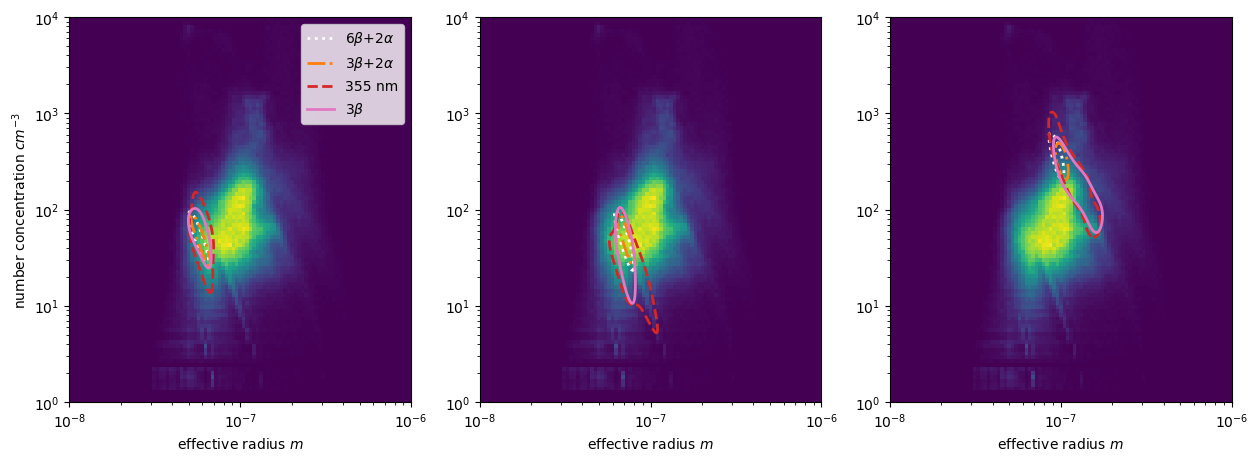

In [97]:
ex_idx_lst = [9, 42, 73]
fig,ax_lst = plt.subplots(1,len(ex_idx_lst),figsize=(5*len(ex_idx_lst),5))
for plt_idx, ex_idx in enumerate(ex_idx_lst):
    ax = ax_lst[plt_idx]
    
    ax.pcolormesh(hist_full[1],hist_full[2],hist_full[0].T)
    
    for m_idx, ds in enumerate(ds_lst):
        f_pdf = ds['nn_pdf_examples'].isel(example_idx=ex_idx).values
        contour_levels = np.linspace(f_pdf.min(), f_pdf.max(),100)
        contplt = contours = ax.contour(ds['nn_rad_bins'],ds['nn_conc_bins'], f_pdf, levels = [contour_levels[10]],linewidths=2,**contour_def_lst[m_idx])
        
    # 2. Create proxy artists using your definitions
    artists_lst = [
        Line2D([0], [0], color=style['colors'], linestyle=style['linestyles'], lw=2) 
        for style in contour_def_lst
    ]
        
    if plt_idx == 0:
        ax.legend(artists_lst, custom_label_lst)
        ax.set_ylabel(r'number concentration $cm^{-3}$')
    
    ax.set_xlim([hist_full[1][0],hist_full[1][-1]])
    ax.set_ylim([hist_full[2][0],hist_full[2][-1]])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'effective radius $m$')
    
    # ax.set_title("Full Dataset Distribution")

save_fig_name = "GlobalPDF_Example_"+"_".join([str(x) for x in ex_idx_lst])+".png"
plt.savefig(os.path.join(save_fig_path,save_fig_name), dpi=300, bbox_inches='tight')

In [96]:
"GlobalPDF_Example_"+"_".join([str(x) for x in ex_idx_lst])+".png"

'GlobalPDF_Example_9_42_73.png'

In [132]:
test_ds.sizes['data_index']

1144606

In [144]:
idx_arr = (np.random.rand(150)*test_ds.sizes['data_index']).astype(int)

In [146]:
idx_arr

array([ 378522,  593729, 1041362,  717119,   48150,  635869,  926980,
        137710,  303504,  894220,  653744,  109183,  838026,   72911,
        791867,   91345,  479735, 1074203,   68518, 1085864,  664193,
        430965, 1078857,  975595,  721214,  824936,  477459,  103382,
       1002878,  990327,  557148,  820133, 1056277,  777505,  835633,
        792242,  940092,  817533,  564972,  252295,   69655, 1121670,
         14823,  601163,  773041,  231152, 1026252,  429214,  669218,
        857646,  684716,  882426,  531865,  728651,  543995,  830339,
        356460,  134732,  472545, 1033691,  571859,  187639, 1039548,
       1070737,  709717,  821860, 1134148,  455711,  545662, 1065300,
        559200,  692848,  311547,  727411, 1128726, 1096914,  218639,
         42582,  812045,  640661,   98643,   89202,  976381,   43838,
        871662,  403116,  950898,    6915,  772075,  154701,  519375,
       1095816,  600820,  295350,  946051, 1073333,  120368,    6384,
        758016,  181

In [140]:
idx_arr = (np.random.rand(20)*150).astype(int)

In [141]:
tarr = np.random.rand(300).reshape(150,2)

In [143]:
tarr[idx_arr,:].shape

(20, 2)

In [217]:
test_ds

<xarray.Dataset> Size: 3GB
Dimensions:                  (wavelength: 6, real_index_refraction: 7,
                              imag_index_refraction: 4, data_index: 1144606)
Coordinates:
  * wavelength               (wavelength) float64 48B 1.064e-06 ... 3.55e-07
  * real_index_refraction    (real_index_refraction) float64 56B 1.3 ... 1.6
  * imag_index_refraction    (imag_index_refraction) float64 32B 0.0 ... 0.06
  * data_index               (data_index) int64 9MB 0 1 2 ... 1144604 1144605
Data variables: (12/15)
    backscatter_coefficient  (wavelength, real_index_refraction, imag_index_refraction, data_index) float64 2GB ...
    extinction_coefficient   (wavelength, real_index_refraction, imag_index_refraction, data_index) float64 2GB ...
    number_concentration     (data_index) float32 5MB ...
    mean_r                   (data_index) float32 5MB ...
    mean_r_2                 (data_index) float32 5MB ...
    mean_r_3                 (data_index) float32 5MB ...
    ...                       ...
    file_name                (data_index) <U14 64MB ...
    project_name             (data_index) <U7 32MB ...
    GGLAT                    (data_index) float32 5MB ...
    GGLON                    (data_index) float32 5MB ...
    GGALT                    (data_index) float32 5MB ...
    Time                     (data_index) datetime64[ns] 9MB ...
Attributes:
    description:        UHSAS aerosol data products of mean radius and number...
    projects:           HIPPO-1, HIPPO-2, HIPPO-3, HIPPO-4, HIPPO-5
    lidar_wavelengths:  1064.00, 710.00, 800.00, 532.00, 400.00, 355.00

In [221]:
4*7*1144606

32048968

In [222]:
32048968/3283252

9.761348809046641

In [223]:
200e3/3283252

0.06091521454947717

# Load Models

In [16]:
for m_idx, model_str in enumerate(model_str_lst):
    print(f"loading model {m_idx+1} of {len(model_str_lst)}")
    conf_reload, model_reload = evid_nn.load_poly_nn_model(model_str,name_str='hyper_best',device=device,path=model_path)
    

loading model 1 of 1
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/


In [18]:
# conf_reload

In [ ]:
conf_lst = []

# r_centroid_arr_lst = []
# n_centroid_arr_lst = []
# r2_centroid_arr_lst = []
# n2_centroid_arr_lst = []
# r_act_arr_lst = []
# n_act_arr_lst = []
# p_model_arr_lst = []

x_rescale_lst = []
y_rescale_lst = []

label_param_lst_lst = []
label_wl_lst_lst = []

# r_interval_arr_lst = []
# n_interval_arr_lst = []

# r_sim_hist_lst_lst = []
# n_sim_hist_lst_lst = []

# sim_hist_in_data_lst_lst = []

f_pdf_arr_lst = []
f_pdf_ens_arr_lst = []
h_pdf_arr_lst = []

# r_ens_centroid_arr_lst = []
# n_ens_centroid_arr_lst = []
# r2_ens_centroid_arr_lst = []
# n2_ens_centroid_arr_lst = []
# r_ens_interval_arr_lst = []
# n_ens_interval_arr_lst = []

hist_nll_lst = []
hist_eval_idx_lst = []
f_pdf_nll_lst = []


for m_idx, model_str in enumerate(model_str_lst):
    print(f"loading model {m_idx+1} of {len(model_str_lst)}")
    conf_reload, model_reload = evid_nn.load_poly_nn_model(model_str,name_str='hyper_best',device=device,path=model_path)

    conf_reload['data']['data_path'] = "/export/breeze1/mhayman/aerosol_poly_nn/datasets/"
    conf_reload['data']['valid_data_path'] = "/export/breeze1/mhayman/aerosol_poly_nn/datasets/"
    conf_reload['data']['test_data_path'] = "/export/breeze1/mhayman/aerosol_poly_nn/datasets/"

    x_scaler = evid_nn.rescale(0,1)
    x_scaler.set_config(**conf_reload['save_model']['x_scaler'])
    y_scaler = evid_nn.rescale(0,1)
    y_scaler.set_config(**conf_reload['save_model']['y_scaler'])

    x_rescale_lst.append(x_scaler)
    y_rescale_lst.append(y_scaler)

    conf_lst.append(conf_reload)
    conf = conf_reload
    dtype = model_reload.dtype

    nc_attrs = {'model':model_str}

    # if m_idx == 0:
    #     intrp_tnsr = torch.tensor(percentile_lst,dtype=dtype,device=device)

    
    label_param_lst = []
    label_wl_lst = []
    
    if 'extinction_coefficient' in conf_reload['data']['wavelength_inputs']:
        label_param_lst.append(r"$\alpha$")
        wl_key='extinction_coefficient'
    if 'backscatter_coefficient' in conf_reload['data']['wavelength_inputs']:
        label_param_lst.append(r"$\beta$")
        wl_key='backscatter_coefficient'

    for wl in conf_reload['data']['wavelength_inputs'][wl_key]['wavelength_lst']:
        label_wl_lst.append(str(int(wl*1e9)))

    label_param_lst_lst.append(label_param_lst)
    label_wl_lst_lst.append(label_wl_lst)


    ### Load Data ###
    # this is repeated because rescaling could theoretically be different between models
    
    override_validation = False  # forces the validation data to be split from training

    rank = 0
    trial = False
    
    
    ds = xr.open_dataset(os.path.join(conf['data']['data_path'],conf['data']['data_file']))
    
    train_batch_size = conf['data']['batch_size']
    valid_batch_size = conf['data']['batch_size']
    test_batch_size = 256 # conf['data']['batch_size']
    
    train_idx = int(np.round(ds.sizes['data_index']*conf['data']['train_fraction']))
    valid_idx = train_idx+int(np.round(ds.sizes['data_index']*conf['data']['valid_fraction']))
    test_idx = train_idx+int(np.round(ds.sizes['data_index']*conf['data']['test_fraction']))
    
    
    train_input_arr, train_label_arr, input_str_lst, output_str_lst, input_frac_uncertainty = data.build_training_array(ds,conf)
    
    if not override_validation:
        # valid_ds = xr.open_dataset(os.path.join(conf['data']['valid_data_path'],conf['data']['valid_data_file']))
        
        
        # valid_input_arr, valid_label_arr, _, _, _ = data.build_training_array(valid_ds,conf)
        
        x_train = x_scaler.scale(np.log(train_input_arr.values))
        # x_valid = x_scaler.scale(np.log(valid_input_arr.values))
        
        y_train = y_scaler.scale(np.log(train_label_arr.values))
        # y_valid = y_scaler.scale(np.log(valid_label_arr.values))
    else:
        print("validation dataset encountered an error:")
        print("override_validation=True, so validation is split from training data")
        # print(str(E))
        x_train = x_scaler.scale(np.log(train_input_arr.values[:train_idx,:]))
        # x_valid = x_scaler.scale(np.log(train_input_arr.values[train_idx:valid_idx,:]))
        
        y_train = y_scaler.scale(np.log(train_label_arr.values[:train_idx,:]))
        # y_valid = y_scaler.scale(np.log(train_label_arr.values[train_idx:valid_idx,:]))
    
    
    cond_args = conf['data']['cond_args']
    
    train_dataset = evid_nn.EvidDataset(x_train,y_train,
                                dtype=dtype,device=device,
                                **cond_args)
    # valid_dataset = evid_nn.EvidDataset(x_valid,y_valid,
    #                             dtype=dtype,device=device,
    #                             **cond_args)
    # test_dataset = evid_nn.EvidDataset(x_test,y_test,
    #                             dtype=dtype,device=device,
    #                             **cond_args)
    
    train_dataloader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    # valid_dataloader = DataLoader(valid_dataset, batch_size=valid_batch_size, shuffle=True)

    # use the training data to estimate histgrams with bin widths optimized using validation data
    # then evaluate the NLL of those PDFs on the test data.  Compare the result to the ML solution.
    # building the histograms requires we do a grid search over all possible inputs
    
    
    test_ds = xr.open_dataset(os.path.join(conf['data']['test_data_path'],conf['data']['test_data_file']))
    
    test_input_arr, test_label_arr, _, _, _ = data.build_training_array(test_ds,conf)
    
    x_test = x_scaler.scale(np.log(test_input_arr.values))
    
    y_test = y_scaler.scale(np.log(test_label_arr.values))
    
    test_dataset = evid_nn.EvidDataset(x_test,y_test,
                                dtype=dtype,device=device,
                                **cond_args)
    
    test_dataloader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

    ### End Data Loader ###

    # in_data = x_train
    # out_label = y_train
    
    # in_data = x_valid
    # out_label = y_valid

    ### Perform example analysis ###
    # actual sample data
    in_data = x_test
    out_label = y_test

    y_pred_lst = []
    with torch.no_grad():
        # calculate the loss for all test points
        # for k, (x,label_data) in enumerate(test_dataloader):
        for (x,label_data) in tqdm(test_dataloader, desc="NN Test Progress"):
            # y_pred_batch = model_reload(x,label_data).detach().cpu().numpy()
            fit_coef = model_reload.net(x)
            loss = model_reload.fpdf_nll(fit_coef,label_data)
            # y_pred_lst.append(loss.cpu()) # Move to CPU here
            y_pred_lst.append(loss)
    y_pred = torch.concat(y_pred_lst).detach().cpu().numpy()
    




    ### Calculate the histogram solution 
    hist_in_pt  = model_opt_hist_dct[model_str]["input_bins"]
    hist_out_pt = model_opt_hist_dct[model_str]["output_bins"]

    N_samples = x_train.shape[0]
    D_in = x_train.shape[1]
    D_out = y_train.shape[1]
    
    x_bins = np.clip(np.floor(x_train * hist_in_pt).astype(int), 0, hist_in_pt - 1)
            
    # 2. Digitize Outputs
    y_bins = np.clip(np.floor(y_train * hist_out_pt).astype(int), 0, hist_out_pt - 1)

    
    # 3. Stack inputs and outputs into a single array of shape (N_samples, D_in + D_out)
    combined_bins = np.hstack((x_bins, y_bins))
    
    # 4. Find all unique populated bins and count their frequencies
    # This completely skips any empty bins in your high-dimensional grid.
    unique_combinations, counts = np.unique(combined_bins, axis=0, return_counts=True)

    # 1. Digitize validation inputs and outputs
    x_valid_bins = np.clip(np.floor(in_data * hist_in_pt).astype(int), 0, hist_in_pt - 1)
    y_valid_bins = np.clip(np.floor(out_label * hist_out_pt).astype(int), 0, hist_out_pt - 1)


    # 2. Stack them into a single array of shape (N_samples, D_in + D_out)
    valid_combined_bins = np.hstack((x_valid_bins, y_valid_bins))
    
    # Helper function to view a 2D array of coordinates as a 1D array of bytes
    def view1d(a):
        a = np.ascontiguousarray(a)
        return a.view(np.dtype((np.void, a.dtype.itemsize * a.shape[1]))).ravel()
    
    # Create 1D views of our joint bins
    train_1d = view1d(unique_combinations)
    valid_1d = view1d(valid_combined_bins)
    
    # np.unique(..., axis=0) naturally sorts its output, so train_1d is already sorted!
    # We find where each validation point would be inserted into the training bins
    insert_idx = np.searchsorted(train_1d, valid_1d)
    
    # Protect against validation points that fall completely outside the training range
    insert_idx = np.clip(insert_idx, 0, len(train_1d) - 1)
    
    # Check which validation points actually perfectly matched a populated training bin
    match_mask = (train_1d[insert_idx] == valid_1d)
    
    # Extract the joint counts! Validation points that land in empty bins get 0.
    valid_joint_counts = np.zeros(len(valid_combined_bins), dtype=counts.dtype)
    valid_joint_counts[match_mask] = counts[insert_idx[match_mask]]
    
    # Extract just the input coordinates from the unique training bins
    train_x_bins = unique_combinations[:, :D_in]
    
    # Find the unique input bins and map every original row to its unique input index
    _, x_inv_idx = np.unique(train_x_bins, axis=0, return_inverse=True)
    
    # Sum the counts for all outputs sharing the same input bin
    marginal_x_counts = np.bincount(x_inv_idx, weights=counts)
    
    # Now apply the same 1D lookup trick to map marginal_x_counts to the validation points
    train_x_1d = view1d(unique_combinations[np.unique(x_inv_idx, return_index=True)[1], :D_in])
    valid_x_1d = view1d(x_valid_bins)
    
    idx_x = np.searchsorted(train_x_1d, valid_x_1d)
    idx_x = np.clip(idx_x, 0, len(train_x_1d) - 1)
    match_x_mask = (train_x_1d[idx_x] == valid_x_1d)
    
    valid_marginal_counts = np.zeros(len(x_valid_bins), dtype=float)
    valid_marginal_counts[match_x_mask] = marginal_x_counts[idx_x[match_x_mask]]
    
    # Calculate the conditional probability P(Y_bin | X_bin)
    # Avoid division by zero for inputs that were never seen in training
    with np.errstate(divide='ignore', invalid='ignore'):
        conditional_prob = np.where(
            valid_marginal_counts > 0, 
            valid_joint_counts / valid_marginal_counts, 
            0.0
        )
    # when the histogram is zero at the target location, this presents a problem for using the histogram to evaluate the NLL
    eval_idx = np.where(conditional_prob > 0)
    hist_nll = -np.log(conditional_prob[eval_idx]/(1.0/hist_out_pt)**2)  # use sum (instead of mean) to penalize missing data points that aren't included?
    print(f"input bins {hist_in_pt}, output bins {hist_out_pt}: {np.sum(hist_nll)}")


    print(f"NN: {np.sum(y_pred[eval_idx])}")
    print(f"NN unfiltered: {np.sum(y_pred)}")
    print()

    hist_nll_lst.append(hist_nll)
    hist_eval_idx_lst.append(eval_idx)
    f_pdf_nll_lst.append(y_pred)

    # h_in_cnt_lst.append(hist_in_pt)
    # h_out_cnt_lst.append(hist_out_pt)
    # h_vld_lst.append(hist_nll)

    

    # # data for histogram analysis
    # hist_in_data = np.concatenate([x_train,x_valid,x_test],axis=0)
    # hist_out_label = np.concatenate([y_train,y_valid,y_test],axis=0)

    # if m_idx == 0:
    #     # idx_arr = (np.random.rand(example_count)*in_data.shape[0]).astype(int)  # get random input
    #     r_act = out_label[:,1][idx_arr]
    #     n_act = out_label[:,0][idx_arr]
        
    # sim_idx_lst = []
    # r_sim_hist_lst = []
    # n_sim_hist_lst = []
    # sim_hist_in_data_lst = []
    # for sidx in range(idx_arr.size):
    #     idx = idx_arr[sidx]
    #     sim_idx = np.where(np.prod(np.abs(hist_in_data - in_data[idx,:].reshape(1,-1)) < hist_width,axis=1))
    #     sim_idx_lst.append(sim_idx)

    #     sim_hist_in_data_lst.append(hist_in_data[sim_idx])

    #     r_sim_hist = hist_out_label[:,1][sim_idx]
    #     n_sim_hist = hist_out_label[:,0][sim_idx]

    #     r_sim_hist_lst.append(r_sim_hist)
    #     n_sim_hist_lst.append(n_sim_hist)

    # r_sim_hist_lst_lst.append(r_sim_hist_lst)
    # n_sim_hist_lst_lst.append(n_sim_hist_lst)
    # sim_hist_in_data_lst_lst.append(sim_hist_in_data_lst)

    # pdf_ax = np.exp(y_scaler.unscale(np.stack([x_plt,x_plt],axis=1)))
    # hist_ax = np.exp(y_scaler.unscale(np.stack([h_part[1],h_part[2]],axis=1)))
    # act_ax = np.exp(y_scaler.unscale(np.stack([np.array([n_act]),np.array([r_act])],axis=1))).squeeze()

    # pdf_ax_lst.append(pdf_ax)
    # hist_ax_lst.append(hist_ax)
    # act_ax_lst.append(act_ax)
        

    f_pdf_lst = []
    f_pdf_ens_lst = []
    with torch.no_grad():
        # for sidx, sim_idx in enumerate(sim_idx_lst):
        # for sidx in range(idx_arr.size):
        for sidx in tqdm(range(idx_arr.size), desc="Example case progress"):
            idx = idx_arr[sidx]
            f_pdf_tnsr = model_reload.output_pdf(torch.tensor(in_data[idx:(idx+1),:],dtype=dtype,device=device))
            f_pdf = f_pdf_tnsr.detach().cpu().numpy()
            x_plt = model_reload.x_int.detach().cpu().numpy()
            
            ensemble_size = 100
            # ensemble_width = hist_width # (observation uncertainty)
            ensemble_width = 1.0/hist_in_pt # (observation uncertainty) set by optimized histogram analysis
            loop_length = 4
            f_pdf_ens = np.zeros((f_pdf.shape[1],f_pdf.shape[2]))
            for ens_group_idx in range(loop_length):
                f_pdf_ens_tnsr = model_reload.output_pdf(torch.tensor(in_data[idx:(idx+1),:]+(np.random.rand(ensemble_size,in_data.shape[1])*2-1)*ensemble_width,dtype=dtype,device=device))
                f_pdf_ens += np.sum(f_pdf_ens_tnsr.detach().cpu().numpy(),axis=0)
                # print(ens_group_idx)
            
            f_pdf_ens = f_pdf_ens/(loop_length*ensemble_size)
            f_pdf_ens_lst.append(f_pdf_ens)
            
            f_pdf_lst.append(f_pdf)

    f_pdf_arr_lst.append(np.concatenate(f_pdf_lst,axis=0))
    f_pdf_ens_arr_lst.append(np.stack(f_pdf_ens_lst,axis=0))

    h_pdf_lst = []
    for sidx in range(idx_arr.size):
        idx = idx_arr[sidx]
        
        # store the histogram version of the PDF
        # Example: We want the 2D output distribution for input bin [5, 2, 8, 1]
        # target_input_bin = np.array([5, 5, 8, 1, 4])
        target_input_bin = np.clip(np.floor(in_data[idx,:] * hist_in_pt).astype(int), 0, hist_in_pt - 1)
        
        # Create a boolean mask where the input columns match our target
        mask = np.all(unique_combinations[:, :D_in] == target_input_bin, axis=1)
        
        # Filter the arrays using the mask
        output_coords = unique_combinations[mask, D_in:]
        output_counts = counts[mask]
        
        # Reconstruct the 2D histogram for this specific input
        # Initialize an empty 2D grid
        hist_2d = np.zeros((hist_out_pt, hist_out_pt))
        
        # Populate the grid with the counts we found
        if len(output_counts) > 0:
            hist_2d[output_coords[:, 0], output_coords[:, 1]] = output_counts
            hist_2d = hist_2d/np.sum(output_counts)/(1.0/hist_out_pt)**2

        h_pdf_lst.append(hist_2d[np.newaxis,...])
    h_pdf_arr_lst.append(np.concatenate(h_pdf_lst,axis=0))

loading model 1 of 4
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/


/h/eol/mhayman/PythonScripts/aerosol-scattering/library/data.py:202: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  train_input_arr = xr.concat(input_lst, pd.Index(input_str_lst, name='input_vars'))
/h/eol/mhayman/PythonScripts/aerosol-scattering/library/data.py:202: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  t

NN Test Progress:   0%|          | 0/12826 [00:00<?, ?it/s]

input bins 53, output bins 43: -12663576.409396565
NN: -16700992.645489417
NN unfiltered: -17604721.35716484



Example case progress:   0%|          | 0/30 [00:00<?, ?it/s]

...

NN Test Progress:   0%|          | 0/12826 [00:00<?, ?it/s]

input bins 114, output bins 43: -12914646.846413221
NN: -14806078.114526587
NN unfiltered: -15813285.193176312



Example case progress:   0%|          | 0/30 [00:00<?, ?it/s]

loading model 3 of 4
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/


NN Test Progress:   0%|          | 0/12826 [00:00<?, ?it/s]

In [ ]:
dtype

NLL analysis should include both with and without points omitted in the histogram analysis (due to insufficient data to produce an output).  This highlights the potential benefit of the NN approach where input data grouping is less critical to producing an accurate output solution.

Potential benefits to the NN approach over the histogram.  On the input side, it avoids the need for direct data grouping which discritizes the input space and means some inputs will not produce an output.  It also avoids over aggregation of inputs that smear out the output PDF.  On the output size it avoids overly noisy outputs (bin sizes too small) and overly coarse outputs (bin sizes too large) while producing a continuous output PDF.

In [12]:
for idx, hist_nll in enumerate(hist_nll_lst):
    print(f"Model {idx}")
    print(f"Histogram test NLL: {np.sum(hist_nll)}")
    print(f"filtered point count: {f_pdf_nll_lst[idx].size - hist_eval_idx_lst[idx][0].size}")
    print(f"NN test NLL (filtered): {np.sum(f_pdf_nll_lst[idx][hist_eval_idx_lst[idx]])}")
    print(f"NN test NLL (unfiltered): {np.sum(f_pdf_nll_lst[idx])}")

Model 0
Histogram test NLL: -12663576.409396565
filtered point count: 207332
NN test NLL (filtered): -16700992.645489417
NN test NLL (unfiltered): -17604721.35716484
Model 1
Histogram test NLL: -12914646.846413221
filtered point count: 260602
NN test NLL (filtered): -14806078.114526587
NN test NLL (unfiltered): -15813285.193176312
Model 2
Histogram test NLL: -11327160.659983002
filtered point count: 76926
NN test NLL (filtered): -11329437.949366042
NN test NLL (unfiltered): -11458177.71067091
Model 3
Histogram test NLL: -11435639.67684567
filtered point count: 101998
NN test NLL (filtered): -11387385.670924643
NN test NLL (unfiltered): -11585498.95535871


In [ ]:
# hist_nll_lst.append(hist_nll)
# hist_eval_idx_lst.append(eval_idx)
# f_pdf_nll_lst.append(y_pred)

(-10.0, 10.0)

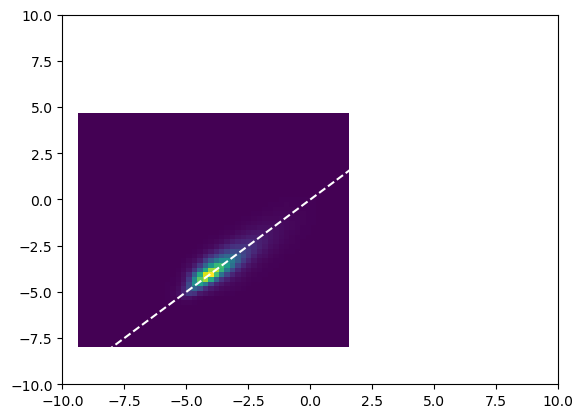

In [56]:
idx=3
plt.figure()
plt.hist2d(hist_nll_lst[idx],f_pdf_nll_lst[idx][hist_eval_idx_lst[idx]],bins=50)
plt.plot([-10,10],[-10,10],'w--')
plt.ylim([-10,10])
plt.xlim([-10,10])


In [34]:
conf['data']['batch_size']

1018

In [35]:
x.shape

torch.Size([256, 8])

In [29]:
loss

tensor([-4.9900, -5.6790, -5.9130, -5.7496, -5.4919, -5.9854, -6.0489, -5.6923,
        -5.9920, -6.2353, -6.2443, -5.9663, -6.4900, -6.5295, -6.4224, -6.1323,
        -6.7280, -6.6603, -6.5244, -6.2899, -6.7135, -6.6541, -6.5499, -6.3746,
        -4.4468, -4.9783, -5.2707, -5.2853, -4.8836, -5.1399, -5.0499, -4.5673,
        -4.9522, -5.1039, -4.9205, -4.3354, -4.9317, -5.1188, -4.9802, -4.4380,
        -4.9049, -5.0825, -4.9849, -4.6012, -4.9767, -5.0059, -4.8886, -4.5013,
        -5.2660, -5.0534, -4.7943, -4.3673], device='cuda:0',
       dtype=torch.float64)

In [17]:
model_reload.device

device(type='cuda', index=0)

In [20]:
model_reload(x,label_data)

tensor(-1437.5477, device='cuda:0', dtype=torch.float64,
       grad_fn=<SumBackward0>)

In [24]:
k

12825

In [25]:
len(test_dataloader)

12826

In [26]:
len(train_dataloader)

20212

In [27]:
x_test.shape

(3283252, 8)

In [28]:
x_train.shape

(20292524, 8)

# Plot example PDFs

In [13]:
custom_label_lst = [r'2$\alpha$ 6$\beta$',r'2$\alpha$ 3$\beta$', r'355 nm',r'532 nm']

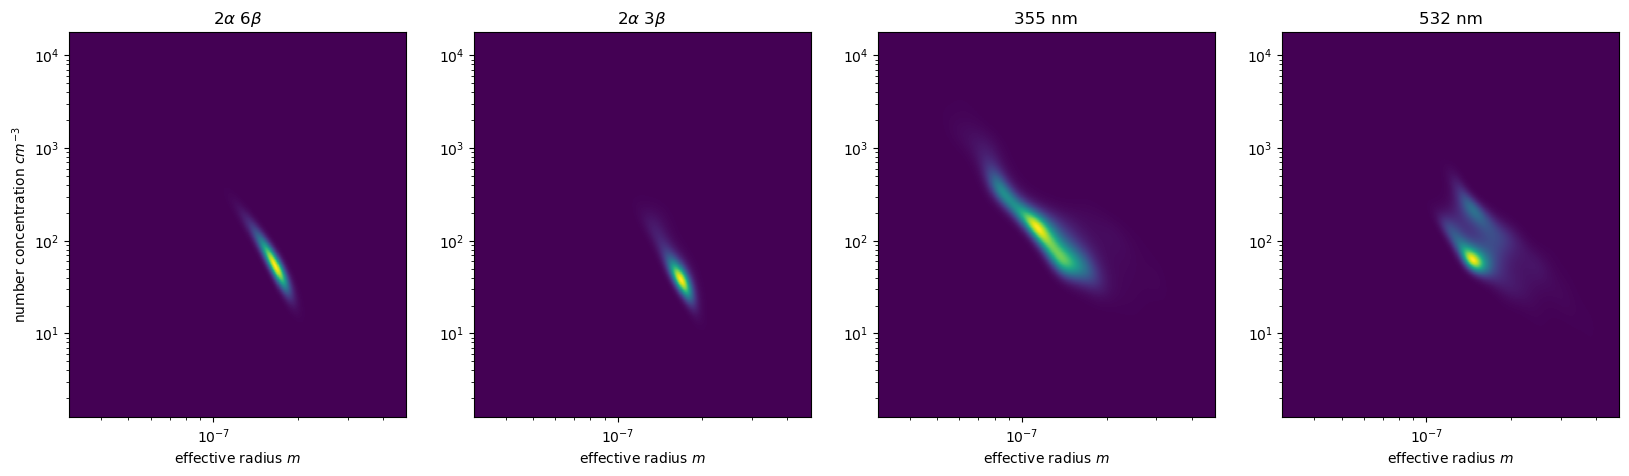

In [14]:
ex_idx = 15
n_col = 4
n_row = int(np.ceil(len(f_pdf_arr_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, hn_2d in enumerate(f_pdf_arr_lst):
    pdf_ax = np.exp(y_rescale_lst[m_idx].unscale(np.stack([x_plt,x_plt],axis=1)))
    # f_pdf = f_pdf_ens_arr_lst[m_idx][ex_idx,...]
    f_pdf = f_pdf_arr_lst[m_idx][ex_idx,...]
    ax = ax_lst[m_idx]
    ax.pcolormesh(pdf_ax[:,1],pdf_ax[:,0],f_pdf)
    # ax.pcolormesh(pdf_ax[:,1],pdf_ax[:,0],f_pdf[0,...]/np.sum(f_pdf[0,...]))
    ax.set_xscale('log')
    ax.set_yscale('log')
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'effective radius $m$')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'number concentration $cm^{-3}$')
    title = custom_label_lst[m_idx]
    # title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

IndexError: list index out of range

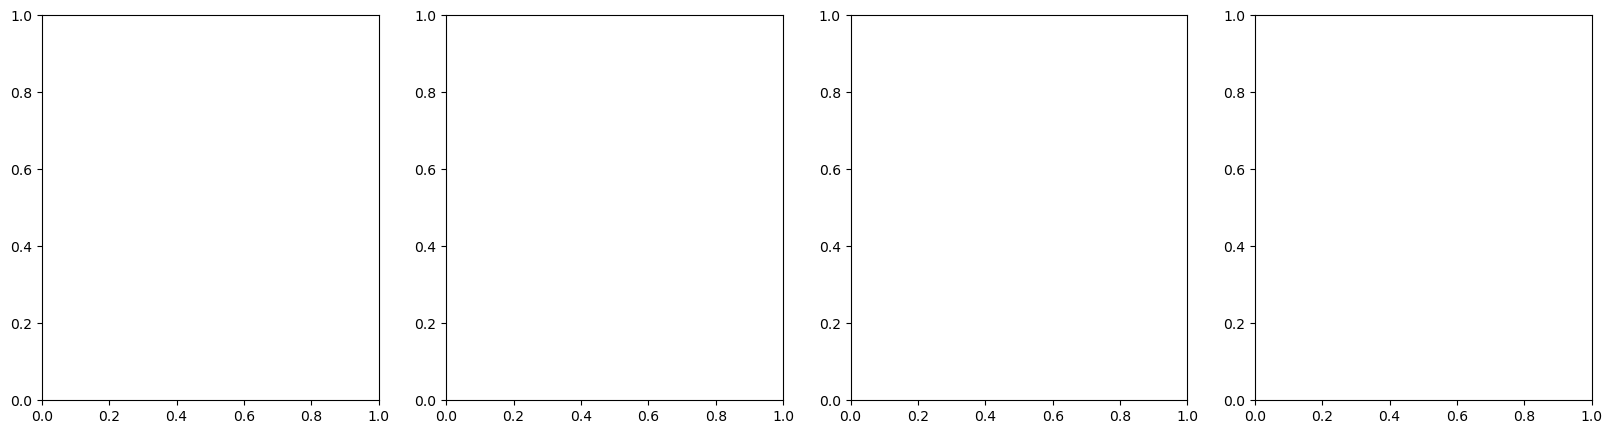

In [15]:
n_col = 4
n_row = int(np.ceil(len(f_pdf_arr_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, hn_2d in enumerate(f_pdf_arr_lst):
    pdf_ax = np.exp(y_rescale_lst[m_idx].unscale(np.stack([x_plt,x_plt],axis=1)))
    f_pdf = f_pdf_ens_arr_lst[m_idx][ex_idx,...]
    # f_pdf = f_pdf_arr_lst[m_idx][ex_idx,...]
    ax = ax_lst[m_idx]
    ax.pcolormesh(pdf_ax[:,1],pdf_ax[:,0],f_pdf)
    # ax.pcolormesh(pdf_ax[:,1],pdf_ax[:,0],f_pdf[0,...]/np.sum(f_pdf[0,...]))
    ax.set_xscale('log')
    ax.set_yscale('log')
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'effective radius $m$')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'number concentration $cm^{-3}$')
    title = custom_label_lst[m_idx]
    # title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

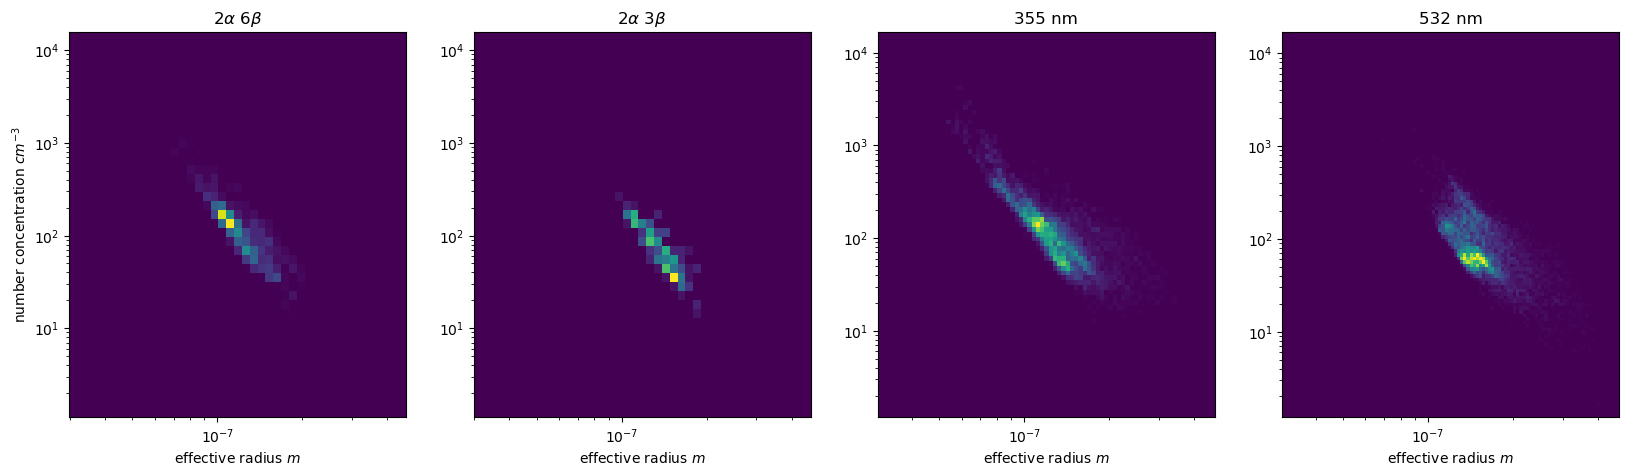

In [70]:
# ex_idx = 15
n_col = 4
n_row = int(np.ceil(len(f_pdf_arr_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, hn_2d in enumerate(f_pdf_arr_lst):
    model_str = list(model_opt_hist_dct.keys())[m_idx]
    # x_h_plt = np.arange(model_opt_hist_dct[model_str]['output_bins'])/100
    x_h_plt = np.arange(model_opt_hist_dct[model_str]['output_bins'])/model_opt_hist_dct[model_str]['output_bins']
    # np.clip(np.floor(in_data * hist_in_pt).astype(int), 0, hist_in_pt - 1)
    hist_ax = np.exp(y_rescale_lst[m_idx].unscale(np.stack([x_h_plt,x_h_plt],axis=1)))
    # f_pdf = f_pdf_ens_arr_lst[m_idx][ex_idx,...]
    f_pdf = h_pdf_arr_lst[m_idx][ex_idx,...]
    ax = ax_lst[m_idx]
    ax.pcolormesh(hist_ax[:,1],hist_ax[:,0],f_pdf)
    # ax.pcolormesh(pdf_ax[:,1],pdf_ax[:,0],f_pdf[0,...]/np.sum(f_pdf[0,...]))
    ax.set_xscale('log')
    ax.set_yscale('log')
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'effective radius $m$')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'number concentration $cm^{-3}$')
    title = custom_label_lst[m_idx]
    # title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)
    # ax.set_xlim([np.min(pdf_ax[:,0]),np.max(pdf_ax[:,0])])
    # ax.set_xlim([np.min(pdf_ax[:,1]),np.max(pdf_ax[:,1])])

In [64]:
hist_ax.shape

(108, 2)

In [67]:
x_h_plot.shape

(43,)

In [68]:
np.stack([x_h_plt,x_h_plt],axis=1).shape

(108, 2)

In [66]:
model_opt_hist_dct[model_str]['output_bins']

43

In [46]:
f_pdf.shape

()

In [47]:
h_pdf_arr_lst[0].shape

(1849,)

# Create Histogram PDFs

In [265]:
# hist_pt_range = np.unique(np.round(np.logspace(1,2,10)).astype(int))
# hist_pt_range = np.array([10])

hist_in_pt_range = np.unique(np.round(np.logspace(1.5,2.5,10)).astype(int))
# hist_in_pt_range = np.array([100])
hist_out_pt_range = np.unique(np.round(np.logspace(1.5,2.3,7)).astype(int))
# hist_out_pt_range = np.array([46])

label_param_lst_lst = []
label_wl_lst_lst = []

model_opt_hist_vld_dct = {}  # same as model_opt_hist_dct above but determined through processing

for m_idx, model_str in enumerate(model_str_lst):
    print(f"loading model {m_idx+1} of {len(model_str_lst)}")
    conf_reload, model_reload = evid_nn.load_poly_nn_model(model_str,name_str='hyper_best',device=device,path=model_path)

    conf_reload['data']['data_path'] = "/export/breeze1/mhayman/aerosol_poly_nn/datasets/"
    conf_reload['data']['valid_data_path'] = "/export/breeze1/mhayman/aerosol_poly_nn/datasets/"
    conf_reload['data']['test_data_path'] = "/export/breeze1/mhayman/aerosol_poly_nn/datasets/"

    h_in_cnt_lst = []
    h_out_cnt_lst = []
    h_vld_lst = []

    x_scaler = evid_nn.rescale(0,1)
    x_scaler.set_config(**conf_reload['save_model']['x_scaler'])
    y_scaler = evid_nn.rescale(0,1)
    y_scaler.set_config(**conf_reload['save_model']['y_scaler'])

    # x_rescale_lst.append(x_scaler)
    # y_rescale_lst.append(y_scaler)

    # conf_lst.append(conf_reload)
    conf = conf_reload
    dtype = model_reload.dtype

    nc_attrs = {'model':model_str}

    # if m_idx == 0:
    #     intrp_tnsr = torch.tensor(percentile_lst,dtype=dtype,device=device)

    
    label_param_lst = []
    label_wl_lst = []
    
    if 'extinction_coefficient' in conf_reload['data']['wavelength_inputs']:
        label_param_lst.append(r"$\alpha$")
        wl_key='extinction_coefficient'
    if 'backscatter_coefficient' in conf_reload['data']['wavelength_inputs']:
        label_param_lst.append(r"$\beta$")
        wl_key='backscatter_coefficient'

    for wl in conf_reload['data']['wavelength_inputs'][wl_key]['wavelength_lst']:
        label_wl_lst.append(str(int(wl*1e9)))

    label_param_lst_lst.append(label_param_lst)
    label_wl_lst_lst.append(label_wl_lst)


    ### Load Data ###
    # this is repeated because rescaling could theoretically be different between models
    
    override_validation = False  # forces the validation data to be split from training

    rank = 0
    trial = False
    
    
    
    ds = xr.open_dataset(os.path.join(conf['data']['data_path'],conf['data']['data_file']))
    
    train_batch_size = conf['data']['batch_size']
    valid_batch_size = conf['data']['batch_size']
    test_batch_size = conf['data']['batch_size']
    
    train_idx = int(np.round(ds.sizes['data_index']*conf['data']['train_fraction']))
    valid_idx = train_idx+int(np.round(ds.sizes['data_index']*conf['data']['valid_fraction']))
    test_idx = train_idx+int(np.round(ds.sizes['data_index']*conf['data']['test_fraction']))
    
    
    train_input_arr, train_label_arr, input_str_lst, output_str_lst, input_frac_uncertainty = data.build_training_array(ds,conf)
    
    if not override_validation:
        valid_ds = xr.open_dataset(os.path.join(conf['data']['valid_data_path'],conf['data']['valid_data_file']))
        
        
        # valid_label_arr = xr.concat(output_lst,pd.Index(conf['data']['output_cols'],name='label_vars'))
        valid_input_arr, valid_label_arr, _, _, _ = data.build_training_array(valid_ds,conf)
        
        x_train = x_scaler.scale(np.log(train_input_arr.values))
        x_valid = x_scaler.scale(np.log(valid_input_arr.values))
        
        y_train = y_scaler.scale(np.log(train_label_arr.values))
        y_valid = y_scaler.scale(np.log(valid_label_arr.values))
    else:
        print("validation dataset encountered an error:")
        print("override_validation=True, so validation is split from training data")
        # print(str(E))
        x_train = x_scaler.scale(np.log(train_input_arr.values[:train_idx,:]))
        x_valid = x_scaler.scale(np.log(train_input_arr.values[train_idx:valid_idx,:]))
        
        y_train = y_scaler.scale(np.log(train_label_arr.values[:train_idx,:]))
        y_valid = y_scaler.scale(np.log(train_label_arr.values[train_idx:valid_idx,:]))



    # Assuming x_train and y_train are already scaled between 0 and 1
    N_samples = x_train.shape[0]
    D_in = x_train.shape[1]
    D_out = y_train.shape[1]
    
    for hist_in_pt in hist_in_pt_range:
    
        # 1. Digitize Inputs: Multiply by bin count and floor to get an integer index.
        # Using np.clip prevents exactly 1.0 from spilling into an out-of-bounds bin index.
        x_bins = np.clip(np.floor(x_train * hist_in_pt).astype(int), 0, hist_in_pt - 1)

        # 1. Digitize validation inputs and outputs
        x_valid_bins = np.clip(np.floor(x_valid * hist_in_pt).astype(int), 0, hist_in_pt - 1)
        
        for hist_out_pt in hist_out_pt_range:
            
            # 2. Digitize Outputs
            y_bins = np.clip(np.floor(y_train * hist_out_pt).astype(int), 0, hist_out_pt - 1)

            # 1. Digitize validation inputs and outputs
            y_valid_bins = np.clip(np.floor(y_valid * hist_out_pt).astype(int), 0, hist_out_pt - 1)
            
            # 3. Stack inputs and outputs into a single array of shape (N_samples, D_in + D_out)
            combined_bins = np.hstack((x_bins, y_bins))
            
            # 4. Find all unique populated bins and count their frequencies
            # This completely skips any empty bins in your high-dimensional grid.
            unique_combinations, counts = np.unique(combined_bins, axis=0, return_counts=True)
            
            # unique_combinations[:, :D_in] represents the input bin coordinates
            # unique_combinations[:, D_in:] represents the output bin coordinates
            # counts contains the number of data points inside each specific joint bin
            
            # --- VALIDATION/SCORING LOGIC GOES HERE ---
            # e.g., mapping these counts to probabilities to evaluate against the validation set
            
            
            # 1. Digitize validation inputs and outputs
            # this is moved earlier in the routine and for loops to avoid repeating unnecesarily
            
            # 2. Stack them into a single array of shape (N_samples, D_in + D_out)
            valid_combined_bins = np.hstack((x_valid_bins, y_valid_bins))
            
            # Helper function to view a 2D array of coordinates as a 1D array of bytes
            def view1d(a):
                a = np.ascontiguousarray(a)
                return a.view(np.dtype((np.void, a.dtype.itemsize * a.shape[1]))).ravel()
            
            # Create 1D views of our joint bins
            train_1d = view1d(unique_combinations)
            valid_1d = view1d(valid_combined_bins)
            
            # np.unique(..., axis=0) naturally sorts its output, so train_1d is already sorted!
            # We find where each validation point would be inserted into the training bins
            insert_idx = np.searchsorted(train_1d, valid_1d)
            
            # Protect against validation points that fall completely outside the training range
            insert_idx = np.clip(insert_idx, 0, len(train_1d) - 1)
            
            # Check which validation points actually perfectly matched a populated training bin
            match_mask = (train_1d[insert_idx] == valid_1d)
            
            # Extract the joint counts! Validation points that land in empty bins get 0.
            valid_joint_counts = np.zeros(len(valid_combined_bins), dtype=counts.dtype)
            valid_joint_counts[match_mask] = counts[insert_idx[match_mask]]
            
            # Extract just the input coordinates from the unique training bins
            train_x_bins = unique_combinations[:, :D_in]
            
            # Find the unique input bins and map every original row to its unique input index
            _, x_inv_idx = np.unique(train_x_bins, axis=0, return_inverse=True)
            
            # Sum the counts for all outputs sharing the same input bin
            marginal_x_counts = np.bincount(x_inv_idx, weights=counts)
            
            # Now apply the same 1D lookup trick to map marginal_x_counts to the validation points
            train_x_1d = view1d(unique_combinations[np.unique(x_inv_idx, return_index=True)[1], :D_in])
            valid_x_1d = view1d(x_valid_bins)
            
            idx_x = np.searchsorted(train_x_1d, valid_x_1d)
            idx_x = np.clip(idx_x, 0, len(train_x_1d) - 1)
            match_x_mask = (train_x_1d[idx_x] == valid_x_1d)
            
            valid_marginal_counts = np.zeros(len(x_valid_bins), dtype=float)
            valid_marginal_counts[match_x_mask] = marginal_x_counts[idx_x[match_x_mask]]
            
            # Calculate the conditional probability P(Y_bin | X_bin)
            # Avoid division by zero for inputs that were never seen in training
            with np.errstate(divide='ignore', invalid='ignore'):
                conditional_prob = np.where(
                    valid_marginal_counts > 0, 
                    valid_joint_counts / valid_marginal_counts, 
                    0.0
                )
            # when the histogram is zero at the target location, this presents a problem for using the histogram to evaluate the NLL
            eval_idx = np.where(conditional_prob > 0)
            hist_nll = np.sum(-np.log(conditional_prob[eval_idx]/(1.0/hist_out_pt)**2))  # use sum (instead of mean) to penalize missing data points that aren't included?
            print(f"input bins {hist_in_pt}, output bins {hist_out_pt}: {hist_nll}")
            h_in_cnt_lst.append(hist_in_pt)
            h_out_cnt_lst.append(hist_out_pt)
            h_vld_lst.append(hist_nll)

    print(f"model: {model_str}")
    opt_idx = np.argmin(h_vld_lst)
    print(f"optimal input bins: {h_in_cnt_lst[opt_idx]}")
    print(f"optimal output bins: {h_out_cnt_lst[opt_idx]}")
    model_opt_hist_vld_dct[model_str] = {"input_bins": h_in_cnt_lst[opt_idx], "output_bins": h_out_cnt_lst[opt_idx]}
                        

    # # evaluate a combination of input and output resolutions to find the optimal combo
    # for hist_in_pt in hist_pt_range:
    #     h_in_bins = np.linspace(0,1,hist_in_pt)
        
    #     for hist_out_pt in hist_pt_range:
    #         h_out_bins = np.linspace(0,1,hist_out_pt)

    #         # now we need to loop over all combinations of inputs determined by h_in_bins for each input and store the histogram
    #         # resulting from it.

loading model 1 of 1
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/


/h/eol/mhayman/PythonScripts/aerosol-scattering/library/data.py:201: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  train_input_arr = xr.concat(input_lst, pd.Index(input_str_lst, name='input_vars'))
/h/eol/mhayman/PythonScripts/aerosol-scattering/library/data.py:201: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  t

input bins 32, output bins 32: -26919785.549484413
input bins 32, output bins 43: -27218950.458032105
input bins 32, output bins 58: -27403659.066508494
input bins 32, output bins 79: -27503928.04998664
input bins 32, output bins 108: -27543848.026867434
input bins 32, output bins 147: -27496515.485925674
input bins 32, output bins 200: -27317471.570118755
input bins 41, output bins 32: -27756205.833349526
input bins 41, output bins 43: -28091621.64489188
input bins 41, output bins 58: -28297640.084319253
input bins 41, output bins 79: -28407678.481205948
input bins 41, output bins 108: -28424222.490961827
input bins 41, output bins 147: -28329660.751227625
input bins 41, output bins 200: -28065867.967116646
input bins 53, output bins 32: -28499197.506586704
input bins 53, output bins 43: -28872863.12634079
input bins 53, output bins 58: -29098298.97922624
input bins 53, output bins 79: -29198702.961220514
input bins 53, output bins 108: -29183000.058325678
input bins 53, output bins 1

In [105]:
for model_str in model_opt_hist_vld_dct:
    print(f"model: {model_str}")
    print(f"optimal input bins: {model_opt_hist_vld_dct[model_str]['input_bins']}")
    print(f"optimal output bins: {model_opt_hist_vld_dct[model_str]['output_bins']}")
    print()

model: 20260310T065310
optimal input bins: 53
optimal output bins: 43

model: 20260311T110300
optimal input bins: 114
optimal output bins: 43

model: 20260324T070054
optimal input bins: 190
optimal output bins: 79

model: 20260327T080000
optimal input bins: 190
optimal output bins: 108



In [93]:
opt_idx = np.argmin(h_vld_lst)
print(f"optimal input bins: {h_in_cnt_lst[opt_idx]}")
print(f"optimal output bins: {h_out_cnt_lst[opt_idx]}")

optimal input bins: 112
optimal output bins: 40


In [96]:
# Example: We want the 2D output distribution for input bin [5, 2, 8, 1]
# target_input_bin = np.array([5, 5, 8, 1, 4])
target_input_bin = np.clip(np.floor(x_valid[83472,:] * hist_in_pt).astype(int), 0, hist_in_pt - 1)

# Create a boolean mask where the input columns match our target
mask = np.all(unique_combinations[:, :D_in] == target_input_bin, axis=1)

# Filter the arrays using the mask
output_coords = unique_combinations[mask, D_in:]
output_counts = counts[mask]

# Reconstruct the 2D histogram for this specific input
# Initialize an empty 2D grid
hist_2d = np.zeros((hist_out_pt, hist_out_pt))

# Populate the grid with the counts we found
if len(output_counts) > 0:
    hist_2d[output_coords[:, 0], output_coords[:, 1]] = output_counts
    hist_2d = hist_2d/np.sum(output_counts)/(1.0/hist_out_pt)**2

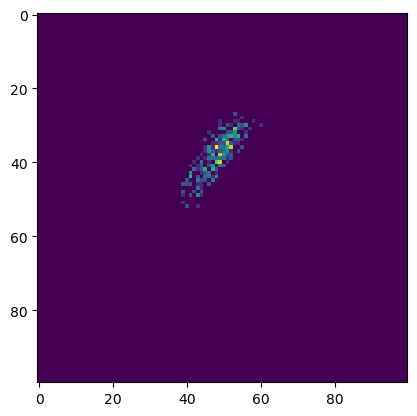

In [97]:
plt.figure()
plt.imshow(hist_2d)

In [7]:
# hist_pt_range = np.logspace(1,3,100)
hist_pt_range = np.array([10])


label_param_lst_lst = []
label_wl_lst_lst = []

for m_idx, model_str in enumerate(model_str_lst):
    print(f"loading model {m_idx+1} of {len(model_str_lst)}")
    conf_reload, model_reload = evid_nn.load_poly_nn_model(model_str,name_str='hyper_best',device=device,path=model_path)

    conf_reload['data']['data_path'] = "/export/breeze1/mhayman/aerosol_poly_nn/datasets/"
    conf_reload['data']['valid_data_path'] = "/export/breeze1/mhayman/aerosol_poly_nn/datasets/"
    conf_reload['data']['test_data_path'] = "/export/breeze1/mhayman/aerosol_poly_nn/datasets/"

    x_scaler = evid_nn.rescale(0,1)
    x_scaler.set_config(**conf_reload['save_model']['x_scaler'])
    y_scaler = evid_nn.rescale(0,1)
    y_scaler.set_config(**conf_reload['save_model']['y_scaler'])

    # x_rescale_lst.append(x_scaler)
    # y_rescale_lst.append(y_scaler)

    # conf_lst.append(conf_reload)
    conf = conf_reload
    dtype = model_reload.dtype

    nc_attrs = {'model':model_str}

    # if m_idx == 0:
    #     intrp_tnsr = torch.tensor(percentile_lst,dtype=dtype,device=device)

    
    label_param_lst = []
    label_wl_lst = []
    
    if 'extinction_coefficient' in conf_reload['data']['wavelength_inputs']:
        label_param_lst.append(r"$\alpha$")
        wl_key='extinction_coefficient'
    if 'backscatter_coefficient' in conf_reload['data']['wavelength_inputs']:
        label_param_lst.append(r"$\beta$")
        wl_key='backscatter_coefficient'

    for wl in conf_reload['data']['wavelength_inputs'][wl_key]['wavelength_lst']:
        label_wl_lst.append(str(int(wl*1e9)))

    label_param_lst_lst.append(label_param_lst)
    label_wl_lst_lst.append(label_wl_lst)


    ### Load Data ###
    # this is repeated because rescaling could theoretically be different between models
    
    override_validation = False  # forces the validation data to be split from training

    rank = 0
    trial = False
    
    
    
    ds = xr.open_dataset(os.path.join(conf['data']['data_path'],conf['data']['data_file']))
    
    train_batch_size = conf['data']['batch_size']
    valid_batch_size = conf['data']['batch_size']
    test_batch_size = conf['data']['batch_size']
    
    train_idx = int(np.round(ds.sizes['data_index']*conf['data']['train_fraction']))
    valid_idx = train_idx+int(np.round(ds.sizes['data_index']*conf['data']['valid_fraction']))
    test_idx = train_idx+int(np.round(ds.sizes['data_index']*conf['data']['test_fraction']))
    
    
    train_input_arr, train_label_arr, input_str_lst, output_str_lst, input_frac_uncertainty = data.build_training_array(ds,conf)
    
    if not override_validation:
        valid_ds = xr.open_dataset(os.path.join(conf['data']['valid_data_path'],conf['data']['valid_data_file']))
        
        
        # valid_label_arr = xr.concat(output_lst,pd.Index(conf['data']['output_cols'],name='label_vars'))
        valid_input_arr, valid_label_arr, _, _, _ = data.build_training_array(valid_ds,conf)
        
        x_train = x_scaler.scale(np.log(train_input_arr.values))
        x_valid = x_scaler.scale(np.log(valid_input_arr.values))
        
        y_train = y_scaler.scale(np.log(train_label_arr.values))
        y_valid = y_scaler.scale(np.log(valid_label_arr.values))
    else:
        print("validation dataset encountered an error:")
        print("override_validation=True, so validation is split from training data")
        # print(str(E))
        x_train = x_scaler.scale(np.log(train_input_arr.values[:train_idx,:]))
        x_valid = x_scaler.scale(np.log(train_input_arr.values[train_idx:valid_idx,:]))
        
        y_train = y_scaler.scale(np.log(train_label_arr.values[:train_idx,:]))
        y_valid = y_scaler.scale(np.log(train_label_arr.values[train_idx:valid_idx,:]))



    # Assuming x_train and y_train are already scaled between 0 and 1
    N_samples = x_train.shape[0]
    D_in = x_train.shape[1]
    D_out = y_train.shape[1]
    
    for hist_in_pt in hist_pt_range:
    
        # 1. Digitize Inputs: Multiply by bin count and floor to get an integer index.
        # Using np.clip prevents exactly 1.0 from spilling into an out-of-bounds bin index.
        x_bins = np.clip(np.floor(x_train * hist_in_pt).astype(int), 0, hist_in_pt - 1)
        
        for hist_out_pt in hist_pt_range:
            
            # 2. Digitize Outputs
            y_bins = np.clip(np.floor(y_train * hist_out_pt).astype(int), 0, hist_out_pt - 1)
            
            # 3. Stack inputs and outputs into a single array of shape (N_samples, D_in + D_out)
            combined_bins = np.hstack((x_bins, y_bins))
            
            # 4. Find all unique populated bins and count their frequencies
            # This completely skips any empty bins in your high-dimensional grid.
            unique_combinations, counts = np.unique(combined_bins, axis=0, return_counts=True)
            
            # unique_combinations[:, :D_in] represents the input bin coordinates
            # unique_combinations[:, D_in:] represents the output bin coordinates
            # counts contains the number of data points inside each specific joint bin
            
            # --- VALIDATION/SCORING LOGIC GOES HERE ---
            # e.g., mapping these counts to probabilities to evaluate against the validation set

            

    # # evaluate a combination of input and output resolutions to find the optimal combo
    # for hist_in_pt in hist_pt_range:
    #     h_in_bins = np.linspace(0,1,hist_in_pt)
        
    #     for hist_out_pt in hist_pt_range:
    #         h_out_bins = np.linspace(0,1,hist_out_pt)

    #         # now we need to loop over all combinations of inputs determined by h_in_bins for each input and store the histogram
    #         # resulting from it.
            

loading model 1 of 1
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/


/h/eol/mhayman/PythonScripts/aerosol-scattering/library/data.py:202: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  train_input_arr = xr.concat(input_lst, pd.Index(input_str_lst, name='input_vars'))
/h/eol/mhayman/PythonScripts/aerosol-scattering/library/data.py:202: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  t

In [36]:
# 1. Digitize validation inputs and outputs
x_valid_bins = np.clip(np.floor(x_valid * hist_in_pt).astype(int), 0, hist_in_pt - 1)
y_valid_bins = np.clip(np.floor(y_valid * hist_out_pt).astype(int), 0, hist_out_pt - 1)

# 2. Stack them into a single array of shape (N_samples, D_in + D_out)
valid_combined_bins = np.hstack((x_valid_bins, y_valid_bins))

# Helper function to view a 2D array of coordinates as a 1D array of bytes
def view1d(a):
    a = np.ascontiguousarray(a)
    return a.view(np.dtype((np.void, a.dtype.itemsize * a.shape[1]))).ravel()

# Create 1D views of our joint bins
train_1d = view1d(unique_combinations)
valid_1d = view1d(valid_combined_bins)

# np.unique(..., axis=0) naturally sorts its output, so train_1d is already sorted!
# We find where each validation point would be inserted into the training bins
insert_idx = np.searchsorted(train_1d, valid_1d)

# Protect against validation points that fall completely outside the training range
insert_idx = np.clip(insert_idx, 0, len(train_1d) - 1)

# Check which validation points actually perfectly matched a populated training bin
match_mask = (train_1d[insert_idx] == valid_1d)

# Extract the joint counts! Validation points that land in empty bins get 0.
valid_joint_counts = np.zeros(len(valid_combined_bins), dtype=counts.dtype)
valid_joint_counts[match_mask] = counts[insert_idx[match_mask]]

# Extract just the input coordinates from the unique training bins
train_x_bins = unique_combinations[:, :D_in]

# Find the unique input bins and map every original row to its unique input index
_, x_inv_idx = np.unique(train_x_bins, axis=0, return_inverse=True)

# Sum the counts for all outputs sharing the same input bin
marginal_x_counts = np.bincount(x_inv_idx, weights=counts)

# Now apply the same 1D lookup trick to map marginal_x_counts to the validation points
train_x_1d = view1d(unique_combinations[np.unique(x_inv_idx, return_index=True)[1], :D_in])
valid_x_1d = view1d(x_valid_bins)

idx_x = np.searchsorted(train_x_1d, valid_x_1d)
idx_x = np.clip(idx_x, 0, len(train_x_1d) - 1)
match_x_mask = (train_x_1d[idx_x] == valid_x_1d)

valid_marginal_counts = np.zeros(len(x_valid_bins), dtype=float)
valid_marginal_counts[match_x_mask] = marginal_x_counts[idx_x[match_x_mask]]

# Calculate the conditional probability P(Y_bin | X_bin)
# Avoid division by zero for inputs that were never seen in training
with np.errstate(divide='ignore', invalid='ignore'):
    conditional_prob = np.where(
        valid_marginal_counts > 0, 
        valid_joint_counts / valid_marginal_counts, 
        0.0
    )

In [79]:
# when the histogram is zero at the target location, this presents a problem for using the histogram to evaluate the NLL
eval_idx = np.where(conditional_prob > 0)
np.sum(-np.log(conditional_prob[eval_idx]/(1.0/hist_out_pt)**2))  # use sum (instead of mean) to penalize missing data points that aren't included?

np.float64(-21375729.76056965)

In [80]:
print(eval_idx[0].size)

8471719


In [46]:
1.0/hist_out_pt

np.float64(0.1)

In [27]:
# x_bins = np.clip(np.floor(x_train * hist_in_pt).astype(int), 0, hist_in_pt - 1)

In [20]:
x_train.shape

(20292524, 5)

In [8]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:                  (wavelength: 6, real_index_refraction: 7,
                              imag_index_refraction: 4, data_index: 724733)
Coordinates:
  * wavelength               (wavelength) float64 48B 1.064e-06 ... 3.55e-07
  * real_index_refraction    (real_index_refraction) float64 56B 1.3 ... 1.6
  * imag_index_refraction    (imag_index_refraction) float64 32B 0.0 ... 0.06
  * data_index               (data_index) int64 6MB 380460 380461 ... 302308
Data variables: (12/15)
    backscatter_coefficient  (wavelength, real_index_refraction, imag_index_refraction, data_index) float64 974MB ...
    extinction_coefficient   (wavelength, real_index_refraction, imag_index_refraction, data_index) float64 974MB ...
    number_concentration     (data_index) float32 3MB 535.3 703.3 ... 359.2
    mean_r                   (data_index) float32 3MB ...
    mean_r_2                 (data_index) float32 3MB ...
    mean_r_3                 (data_index) float32 3MB ...
    ...                       ...
    file_name                (data_index) <U14 41MB ...
    project_name             (data_index) <U7 20MB ...
    GGLAT                    (data_index) float32 3MB ...
    GGLON                    (data_index) float32 3MB ...
    GGALT                    (data_index) float32 3MB ...
    Time                     (data_index) datetime64[ns] 6MB ...
Attributes:
    description:        UHSAS aerosol data products of mean radius and number...
    projects:           HIPPO-1, HIPPO-2, HIPPO-3, HIPPO-4, HIPPO-5
    lidar_wavelengths:  1064.00, 710.00, 800.00, 532.00, 400.00, 355.00

In [13]:
unique_combinations.shape

(2706, 7)

In [53]:
x_valid.shape

(8473192, 5)

Plot a specific histogram case

In [68]:
# Example: We want the 2D output distribution for input bin [5, 2, 8, 1]
# target_input_bin = np.array([5, 5, 8, 1, 4])
target_input_bin = np.clip(np.floor(x_valid[52383,:] * hist_in_pt).astype(int), 0, hist_in_pt - 1)

# Create a boolean mask where the input columns match our target
mask = np.all(unique_combinations[:, :D_in] == target_input_bin, axis=1)

# Filter the arrays using the mask
output_coords = unique_combinations[mask, D_in:]
output_counts = counts[mask]

# Reconstruct the 2D histogram for this specific input
# Initialize an empty 2D grid
hist_2d = np.zeros((hist_out_pt, hist_out_pt))

# Populate the grid with the counts we found
if len(output_counts) > 0:
    hist_2d[output_coords[:, 0], output_coords[:, 1]] = output_counts
    hist_2d = hist_2d/np.sum(output_counts)/(1.0/hist_out_pt)**2

In [69]:
mask.size

2706

In [70]:
np.sum(output_counts)

np.int64(2890199)

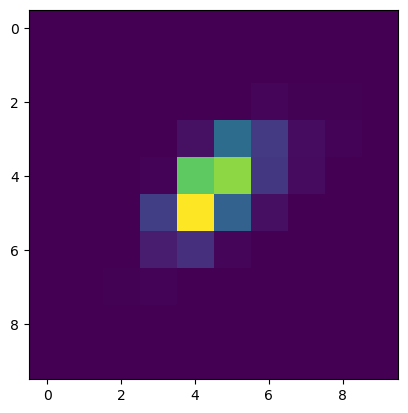

In [71]:
plt.figure()
plt.imshow(hist_2d)

In [72]:
np.sum(hist_2d)

np.float64(99.99999999999999)

In [ ]:
# Example: We want the 2D output distribution for input bin [5, 2, 8, 1]
target_input_bin = np.array([5, 2, 8, 1])

# Create a boolean mask where the input columns match our target
mask = np.all(unique_combinations[:, :D_in] == target_input_bin, axis=1)

# Filter the arrays using the mask
output_coords = unique_combinations[mask, D_in:]
output_counts = counts[mask]

# Reconstruct the 2D histogram for this specific input
# Initialize an empty 2D grid
hist_2d = np.zeros((hist_out_pt, hist_out_pt))

# Populate the grid with the counts we found
if len(output_counts) > 0:
    hist_2d[output_coords[:, 0], output_coords[:, 1]] = output_counts

In [ ]:
conf

In [ ]:
conf_lst = []

r_centroid_arr_lst = []
n_centroid_arr_lst = []
r2_centroid_arr_lst = []
n2_centroid_arr_lst = []
r_act_arr_lst = []
n_act_arr_lst = []
p_model_arr_lst = []

x_rescale_lst = []
y_rescale_lst = []

label_param_lst_lst = []
label_wl_lst_lst = []

r_interval_arr_lst = []
n_interval_arr_lst = []

r_sim_hist_lst_lst = []
n_sim_hist_lst_lst = []

sim_hist_in_data_lst_lst = []

f_pdf_arr_lst = []
f_pdf_ens_arr_lst = []

r_ens_centroid_arr_lst = []
n_ens_centroid_arr_lst = []
r2_ens_centroid_arr_lst = []
n2_ens_centroid_arr_lst = []
r_ens_interval_arr_lst = []
n_ens_interval_arr_lst = []


for m_idx, model_str in enumerate(model_str_lst):
    print(f"loading model {m_idx+1} of {len(model_str_lst)}")
    conf_reload, model_reload = evid_nn.load_poly_nn_model(model_str,name_str='hyper_best',device=device,path=model_path)

    x_scaler = evid_nn.rescale(0,1)
    x_scaler.set_config(**conf_reload['save_model']['x_scaler'])
    y_scaler = evid_nn.rescale(0,1)
    y_scaler.set_config(**conf_reload['save_model']['y_scaler'])

    x_rescale_lst.append(x_scaler)
    y_rescale_lst.append(y_scaler)

    conf_lst.append(conf_reload)
    conf = conf_reload
    dtype = model_reload.dtype

    nc_attrs = {'model':model_str}

    if m_idx == 0:
        intrp_tnsr = torch.tensor(percentile_lst,dtype=dtype,device=device)

    
    label_param_lst = []
    label_wl_lst = []
    
    if 'extinction_coefficient' in conf_reload['data']['wavelength_inputs']:
        label_param_lst.append(r"$\alpha$")
        wl_key='extinction_coefficient'
    if 'backscatter_coefficient' in conf_reload['data']['wavelength_inputs']:
        label_param_lst.append(r"$\beta$")
        wl_key='backscatter_coefficient'

    for wl in conf_reload['data']['wavelength_inputs'][wl_key]['wavelength_lst']:
        label_wl_lst.append(str(int(wl*1e9)))

    label_param_lst_lst.append(label_param_lst)
    label_wl_lst_lst.append(label_wl_lst)


    ### Load Data ###
    # this is repeated because rescaling could theoretically be different between models
    
    override_validation = False  # forces the validation data to be split from training

    rank = 0
    trial = False
    
    
    
    ds = xr.open_dataset(os.path.join(conf['data']['data_path'],conf['data']['data_file']))
    
    train_batch_size = conf['data']['batch_size']
    valid_batch_size = conf['data']['batch_size']
    test_batch_size = conf['data']['batch_size']
    
    train_idx = int(np.round(ds.sizes['data_index']*conf['data']['train_fraction']))
    valid_idx = train_idx+int(np.round(ds.sizes['data_index']*conf['data']['valid_fraction']))
    test_idx = train_idx+int(np.round(ds.sizes['data_index']*conf['data']['test_fraction']))
    
    
    train_input_arr, train_label_arr, input_str_lst, output_str_lst, input_frac_uncertainty = data.build_training_array(ds,conf)
    
    if not override_validation:
        valid_ds = xr.open_dataset(os.path.join(conf['data']['valid_data_path'],conf['data']['valid_data_file']))
        
        
        # valid_label_arr = xr.concat(output_lst,pd.Index(conf['data']['output_cols'],name='label_vars'))
        valid_input_arr, valid_label_arr, _, _, _ = data.build_training_array(valid_ds,conf)
        
        x_train = x_scaler.scale(np.log(train_input_arr.values))
        x_valid = x_scaler.scale(np.log(valid_input_arr.values))
        
        y_train = y_scaler.scale(np.log(train_label_arr.values))
        y_valid = y_scaler.scale(np.log(valid_label_arr.values))
    else:
        print("validation dataset encountered an error:")
        print("override_validation=True, so validation is split from training data")
        # print(str(E))
        x_train = x_scaler.scale(np.log(train_input_arr.values[:train_idx,:]))
        x_valid = x_scaler.scale(np.log(train_input_arr.values[train_idx:valid_idx,:]))
        
        y_train = y_scaler.scale(np.log(train_label_arr.values[:train_idx,:]))
        y_valid = y_scaler.scale(np.log(train_label_arr.values[train_idx:valid_idx,:]))
    
    
    cond_args = conf['data']['cond_args']
    
    train_dataset = evid_nn.EvidDataset(x_train,y_train,
                                dtype=dtype,device=device,
                                **cond_args)
    valid_dataset = evid_nn.EvidDataset(x_valid,y_valid,
                                dtype=dtype,device=device,
                                **cond_args)
    # test_dataset = evid_nn.EvidDataset(x_test,y_test,
    #                             dtype=dtype,device=device,
    #                             **cond_args)
    
    train_dataloader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    valid_dataloader = DataLoader(valid_dataset, batch_size=valid_batch_size, shuffle=True)

    # use the training data to estimate histgrams with bin widths optimized using validation data
    # then evaluate the NLL of those PDFs on the test data.  Compare the result to the ML solution.
    # building the histograms requires we do a grid search over all possible inputs
    
    
    test_ds = xr.open_dataset(os.path.join(conf['data']['test_data_path'],conf['data']['test_data_file']))
    
    test_input_arr, test_label_arr, _, _, _ = data.build_training_array(test_ds,conf)
    
    x_test = x_scaler.scale(np.log(test_input_arr.values))
    
    y_test = y_scaler.scale(np.log(test_label_arr.values))
    
    test_dataset = evid_nn.EvidDataset(x_test,y_test,
                                dtype=dtype,device=device,
                                **cond_args)
    
    test_dataloader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

    ### End Data Loader ###

    # in_data = x_train
    # out_label = y_train
    
    # in_data = x_valid
    # out_label = y_valid

    ### Perform example analysis ###
    # actual sample data
    in_data = x_test
    out_label = y_test

    # data for histogram analysis
    hist_in_data = np.concatenate([x_train,x_valid,x_test],axis=0)
    hist_out_label = np.concatenate([y_train,y_valid,y_test],axis=0)

    if m_idx == 0:
        # idx_arr = (np.random.rand(example_count)*in_data.shape[0]).astype(int)  # get random input
        r_act = out_label[:,1][idx_arr]
        n_act = out_label[:,0][idx_arr]
        
    sim_idx_lst = []
    r_sim_hist_lst = []
    n_sim_hist_lst = []
    sim_hist_in_data_lst = []
    for sidx in range(idx_arr.size):
        idx = idx_arr[sidx]
        sim_idx = np.where(np.prod(np.abs(hist_in_data - in_data[idx,:].reshape(1,-1)) < hist_width,axis=1))
        sim_idx_lst.append(sim_idx)

        sim_hist_in_data_lst.append(hist_in_data[sim_idx])

        r_sim_hist = hist_out_label[:,1][sim_idx]
        n_sim_hist = hist_out_label[:,0][sim_idx]

        r_sim_hist_lst.append(r_sim_hist)
        n_sim_hist_lst.append(n_sim_hist)

    r_sim_hist_lst_lst.append(r_sim_hist_lst)
    n_sim_hist_lst_lst.append(n_sim_hist_lst)
    sim_hist_in_data_lst_lst.append(sim_hist_in_data_lst)

    # pdf_ax = np.exp(y_scaler.unscale(np.stack([x_plt,x_plt],axis=1)))
    # hist_ax = np.exp(y_scaler.unscale(np.stack([h_part[1],h_part[2]],axis=1)))
    # act_ax = np.exp(y_scaler.unscale(np.stack([np.array([n_act]),np.array([r_act])],axis=1))).squeeze()

    # pdf_ax_lst.append(pdf_ax)
    # hist_ax_lst.append(hist_ax)
    # act_ax_lst.append(act_ax)
        

    f_pdf_lst = []
    f_pdf_ens_lst = []
    with torch.no_grad():
        for sidx, sim_idx in enumerate(sim_idx_lst):
            idx = idx_arr[sidx]
            f_pdf_tnsr = model_reload.output_pdf(torch.tensor(in_data[idx:(idx+1),:],dtype=dtype,device=device))
            f_pdf = f_pdf_tnsr.detach().cpu().numpy()
            x_plt = model_reload.x_int.detach().cpu().numpy()
            
            ensemble_size = 100
            ensemble_width = hist_width # (observation uncertainty)
            loop_length = 4
            f_pdf_ens = np.zeros((f_pdf.shape[1],f_pdf.shape[2]))
            for ens_group_idx in range(loop_length):
                f_pdf_ens_tnsr = model_reload.output_pdf(torch.tensor(in_data[idx:(idx+1),:]+(np.random.rand(ensemble_size,in_data.shape[1])*2-1)*ensemble_width,dtype=dtype,device=device))
                f_pdf_ens += np.sum(f_pdf_ens_tnsr.detach().cpu().numpy(),axis=0)
                # print(ens_group_idx)
            
            f_pdf_ens = f_pdf_ens/(loop_length*ensemble_size)

            f_pdf_lst.append(f_pdf)
            f_pdf_ens_lst.append(f_pdf_ens)

    f_pdf_arr_lst.append(np.concatenate(f_pdf_lst,axis=0))
    f_pdf_ens_arr_lst.append(np.stack(f_pdf_ens_lst,axis=0))

In [ ]:
custom_label_lst = [r'2$\alpha$ 6$\beta$',r'2$\alpha$ 3$\beta$', r'355 nm',r'532 nm']

In [ ]:
ex_idx = 15
n_col = 4
n_row = int(np.ceil(len(f_pdf_arr_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, hn_2d in enumerate(f_pdf_arr_lst):
    pdf_ax = np.exp(y_rescale_lst[m_idx].unscale(np.stack([x_plt,x_plt],axis=1)))
    # f_pdf = f_pdf_ens_arr_lst[m_idx][ex_idx,...]
    f_pdf = f_pdf_arr_lst[m_idx][ex_idx,...]
    ax = ax_lst[m_idx]
    ax.pcolormesh(pdf_ax[:,1],pdf_ax[:,0],f_pdf)
    # ax.pcolormesh(pdf_ax[:,1],pdf_ax[:,0],f_pdf[0,...]/np.sum(f_pdf[0,...]))
    ax.set_xscale('log')
    ax.set_yscale('log')
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'effective radius $m$')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'number concentration $cm^{-3}$')
    title = custom_label_lst[m_idx]
    # title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

In [ ]:
n_col = 4
n_row = int(np.ceil(len(f_pdf_ens_arr_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, hn_2d in enumerate(f_pdf_ens_arr_lst):
    pdf_ax = np.exp(y_rescale_lst[m_idx].unscale(np.stack([x_plt,x_plt],axis=1)))
    f_pdf = f_pdf_ens_arr_lst[m_idx][ex_idx,...]
    ax = ax_lst[m_idx]
    ax.pcolormesh(pdf_ax[:,1],pdf_ax[:,0],f_pdf)
    # ax.pcolormesh(pdf_ax[:,1],pdf_ax[:,0],f_pdf[0,...]/np.sum(f_pdf[0,...]))
    ax.set_xscale('log')
    ax.set_yscale('log')
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'effective radius $m$')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'number concentration $cm^{-3}$')
    title = custom_label_lst[m_idx]
    # title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

In [ ]:
n_col = 4
n_row = int(np.ceil(len(y_rescale_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, y_scaler in enumerate(y_rescale_lst):
    h_part = np.histogram2d(r_sim_hist_lst_lst[m_idx][ex_idx],n_sim_hist_lst_lst[m_idx][ex_idx],bins=np.linspace(0,1,500))
    hist_ax = np.exp(y_rescale_lst[m_idx].unscale(np.stack([h_part[1],h_part[2]],axis=1)))
    # pdf_ax = np.exp(y_rescale_lst[m_idx].unscale(np.stack([x_plt,x_plt],axis=1)))
    # f_pdf = f_pdf_arr_lst[m_idx][ex_idx,...]
    ax = ax_lst[m_idx]
    ax.pcolormesh(hist_ax[:,1],hist_ax[:,0],h_part[0].T/np.sum(h_part[0]))

    # add ensemble contour
    pdf_ax = np.exp(y_rescale_lst[m_idx].unscale(np.stack([x_plt,x_plt],axis=1)))
    f_pdf = f_pdf_ens_arr_lst[m_idx][ex_idx,...]
    contours = ax.contour(pdf_ax[:,1],pdf_ax[:,0], f_pdf, levels = 3, colors='white', linestyles=':', linewidths=1)
    
    # ax.pcolormesh(pdf_ax[:,1],pdf_ax[:,0],f_pdf[0,...]/np.sum(f_pdf[0,...]))
    ax.set_xscale('log')
    ax.set_yscale('log')
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'effective radius $m$')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'number concentration $cm^{-3}$')
    title = custom_label_lst[m_idx]
    # title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)

In [ ]:
m_idx = 0  # model index
# ex_idx = 8 # -1  # example index
hist_out_label

# hist_ax = np.exp(y_rescale_lst[-1].unscale(np.stack([0.5*(h_part_total[1][:-1]+h_part_total[1][1:]),
#                                                 0.5*(h_part_total[2][:-1]+h_part_total[2][1:])],axis=1)))

hist_ax = np.exp(y_rescale_lst[-1].unscale(np.stack([0.5*(h_part_total[1][:-1]+h_part_total[1][1:]),
                                                0.5*(h_part_total[2][:-1]+h_part_total[2][1:])],axis=1)))

fig,ax = plt.subplots(1,1,figsize=(5,5))
# ax = ax_lst[m_idx]
# f_pdf = f_pdf_arr_lst[m_idx][ex_idx,...] # direct output
f_pdf = f_pdf_ens_arr_lst[m_idx][ex_idx,...]  # ensemble output
ax.pcolormesh(hist_ax[:,1],hist_ax[:,0],h_part_total[0].T/np.sum(h_part_total[0]))
contours = ax.contour(pdf_ax[:,1],pdf_ax[:,0], f_pdf, levels = 3, colors='white', linestyles=':', linewidths=1)
ax.set_xscale('log')
ax.set_yscale('log')
# if m_idx//n_col == 1:
ax.set_xlabel(r'mean radius $m$')
# if m_idx%n_col == 0:
ax.set_ylabel(r'number concentration $cm^{-3}$')
# title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])

title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
ax.set_title("Prior and "+title)

In [ ]:
ex_idx = 20
n_col = 4
n_row = int(np.ceil(len(y_rescale_lst)/n_col))
fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
for m_idx, hn_2d in enumerate(y_rescale_lst):
    pdf_ax = np.exp(y_rescale_lst[m_idx].unscale(np.stack([x_plt,x_plt],axis=1)))
    # f_pdf = f_pdf_arr_lst[m_idx][ex_idx,...]
    f_pdf = f_pdf_ens_arr_lst[m_idx][ex_idx,...]
    ax = ax_lst[m_idx]
    ax.pcolormesh(hist_ax[:,1],hist_ax[:,0],h_part_total[0].T/np.sum(h_part_total[0]))
    contours = ax.contour(pdf_ax[:,1],pdf_ax[:,0], f_pdf, levels = 3, colors='white', linestyles=':', linewidths=1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    if m_idx//n_col == 1:
        ax.set_xlabel(r'mean radius $m$')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'number concentration $cm^{-3}$')
    title = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax.set_title(title)